### Clustering de accidentes en Medellin

Hacer un modelo de clustering para poder asignar ambulancias y agentes de transito en los diferentes ubicaciones.

1. Librerias y Manipulacion de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
import geopandas as gpd

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Aprendizaje no supervisado/Jerarquización de Vías Urbanas y Rurales.zip'
extract_dir = '/content/vias_extracted'

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f'Files extracted to: {extract_dir}')
print('Contents of the extracted directory:')
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Files extracted to: /content/vias_extracted
Contents of the extracted directory:
/content/vias_extracted/ViasUrbanoRural-07-20.prj
/content/vias_extracted/ViasUrbanoRural-07-20.dbf
/content/vias_extracted/ViasUrbanoRural-07-20.cpg
/content/vias_extracted/ViasUrbanoRural-07-20.shx
/content/vias_extracted/ViasUrbanoRural-07-20.shp


In [ ]:
datos = pd.read_excel('/content/drive/MyDrive/Aprendizaje no supervisado/Accidentalidad_georreferenciada_2018_COMPLETO.xlsx')
datos.head()

,NRO_RADICADO,Latitud,Longitud,CLASE_ACCIDENTE,DIRECCION,CBML,Gravedad Incidente,nombre comuna,Barrio,Diseño,Año,FECHA_ACCIDENTE,HORA_ACCIDENTE,codigo comuna,Comuna,_metodo_lat,_metodo_barrio
0,1611599,6.253440,-75.552931,Caida Ocupante,CR 37 CL 63,0804,Con heridos,Villa Hermosa,La Ladera,Tramo de via,2018,2018-01-01,00:10:00,8,08 - Villa Hermosa,NaN,NaN
1,1611540,6.275106,-75.559833,Choque,CR 50 B CL 81 A,0414,Con heridos,Aranjuez,Brasilia,Interseccion,2018,2018-01-01,00:20:00,4,04 - Aranjuez,NaN,NaN
2,1611518,6.251017,-75.546193,Otro,CL 58 CR 25,0807,Con heridos,Villa Hermosa,Los Mangos,Lote o Predio,2018,2018-01-01,00:20:00,8,08 - Villa Hermosa,NaN,NaN
3,1611589,6.264690,-75.568750,Choque,CL 67 CR 55 AB,0406,Con heridos,Aranjuez,Universidad de Antioquia,Tramo de via,2018,2018-01-01,01:20:00,4,04 - Aranjuez,NaN,NaN
4,1611605,6.264725,-75.545761,Choque,CL 70 CR 33,0309,Con heridos,Manrique,Versalles No. 1,Tramo de via,2018,2018-01-01,01:30:00,3,03 - Manrique,NaN,NaN


In [ ]:
print(datos.shape)
display(datos.describe(include='all'))
print(datos.isna().sum())

(43306, 17)


,NRO_RADICADO,Latitud,Longitud,CLASE_ACCIDENTE,DIRECCION,CBML,Gravedad Incidente,nombre comuna,Barrio,Diseño,Año,FECHA_ACCIDENTE,HORA_ACCIDENTE,codigo comuna,Comuna,_metodo_lat,_metodo_barrio
count,4.330600e+04,43306.000000,43306.000000,43305,43306,38978,43306,43306,42771,43273,43306.0,43306,43306,43306.0,43306,534,3804
unique,NaN,NaN,NaN,6,13950,324,4,22,314,12,NaN,NaN,1026,22.0,22,3,2
top,NaN,NaN,NaN,Choque,CR 999 CL 999,1507,Con heridos,La Candelaria,Las Palmas,Tramo de via,NaN,NaN,17:00:00,10.0,10 - La Candelaria,centroide_comuna,knn_vecino_cercano
freq,NaN,NaN,NaN,30058,386,980,22785,8264,2252,26069,NaN,NaN,830,8264.0,8264,508,3336
mean,1.633495e+06,6.248173,-75.587428,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,2018-07-03 21:09:15.137856256,NaN,NaN,NaN,NaN,NaN
min,2.982600e+04,6.152743,-75.703816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,2018-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN
25%,1.622622e+06,6.225350,-75.592542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,2018-04-05 00:00:00,NaN,NaN,NaN,NaN,NaN
50%,1.633520e+06,6.248022,-75.576195,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,2018-07-05 00:00:00,NaN,NaN,NaN,NaN,NaN
75%,1.644435e+06,6.269238,-75.566527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,2018-10-01 00:00:00,NaN,NaN,NaN,NaN,NaN
max,1.656021e+06,6.342942,-75.502896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,2018-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN


NRO_RADICADO              0
Latitud                   0
Longitud                  0
CLASE_ACCIDENTE           1
DIRECCION                 0
CBML                   4328
Gravedad Incidente        0
nombre comuna             0
Barrio                  535
Diseño                   33
Año                       0
FECHA_ACCIDENTE           0
HORA_ACCIDENTE            0
codigo comuna             0
Comuna                    0
_metodo_lat           42772
_metodo_barrio        39502
dtype: int64


In [ ]:
datos['_coords_confiables'] = True

# Eliminar direcciones fantasma
mask_fantasma = datos['DIRECCION'].str.contains('999', na=False)
datos = datos[~mask_fantasma]

# Eliminar los rellenados por centroide (solo si tienes la columna _metodo_lat)
# Si no la tienes, puedes identificarlos porque 508 registros comparten
# exactamente la misma coordenada dentro de su comuna
datos = datos[datos['_metodo_lat'] != 'centroide_comuna']

print(f"Registros para clustering: {len(datos):,}")

Registros para clustering: 42,056


In [ ]:
# Eliminar coordenada fantasma
mask_fantasma_coords = (
    (datos['Latitud'].round(6)  == 6.221806) &
    (datos['Longitud'].round(6) == -75.703816)
)
print(f"Registros con coordenada fantasma: {mask_fantasma_coords.sum()}")

datos = datos[~mask_fantasma_coords].copy()
print(f"Registros tras eliminar fantasma: {len(datos):,}")

# Limitar al bbox real de Medellín
datos = datos[
    (datos['Latitud'].between(6.17, 6.32)) &
    (datos['Longitud'].between(-75.68, -75.51))
]
print(f"Registros finales para clustering: {len(datos):,}")

Registros con coordenada fantasma: 1683
Registros tras eliminar fantasma: 40,373
Registros finales para clustering: 39,743


In [ ]:
columns_to_drop = ['CBML', '_metodo_lat', '_metodo_barrio', '_coords_confiables','~mask_fantasma_coords']

# Filter out columns that do not exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in datos.columns]

datos = datos.drop(columns=existing_columns_to_drop)
print(datos.shape)

(39743, 14)


In [ ]:
datos = datos.dropna()
datos = datos[datos['Comuna'] != 'Sin Inf']
print(datos.shape)

(39665, 14)


### Analisis Exploratorio

In [ ]:
display(datos.describe(include='all'))

,NRO_RADICADO,Latitud,Longitud,CLASE_ACCIDENTE,DIRECCION,Gravedad Incidente,nombre comuna,Barrio,Diseño,Año,FECHA_ACCIDENTE,HORA_ACCIDENTE,codigo comuna,Comuna
count,3.966500e+04,39665.000000,39665.000000,39665,39665,39665,39665,39665,39665,39665.0,39665,39665,39665.0,39665
unique,NaN,NaN,NaN,6,12003,3,20,313,12,NaN,NaN,984,20.0,20
top,NaN,NaN,NaN,Choque,CR 64 C CL 78,Con heridos,La Candelaria,Campo Amor,Tramo de via,NaN,NaN,17:00:00,10.0,10 - La Candelaria
freq,NaN,NaN,NaN,27815,160,20634,8251,992,23835,NaN,NaN,759,8251.0,8251
mean,1.633443e+06,6.250601,-75.577131,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,2018-07-03 02:57:14.181268224,NaN,NaN,NaN
min,1.611518e+06,6.170115,-75.674481,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,2018-01-01 00:00:00,NaN,NaN,NaN
25%,1.622500e+06,6.232055,-75.586220,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,2018-04-04 00:00:00,NaN,NaN,NaN
50%,1.633289e+06,6.250155,-75.574986,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,2018-07-03 00:00:00,NaN,NaN,NaN
75%,1.644546e+06,6.271949,-75.565497,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,2018-10-02 00:00:00,NaN,NaN,NaN
max,1.656021e+06,6.311991,-75.511802,NaN,NaN,NaN,NaN,NaN,NaN,2018.0,2018-12-31 00:00:00,NaN,NaN,NaN


In [ ]:
datos["HORA"] = pd.to_datetime(datos["HORA_ACCIDENTE"]).dt.hour
datos["RANGO_HORA"] = (datos["HORA"] // 3) * 3
accidentes_rango = datos["RANGO_HORA"].value_counts().sort_index()

print(accidentes_rango)

RANGO_HORA
0      975
3     1503
6     6090
9     5931
12    7253
15    8227
18    6513
21    3173
Name: count, dtype: int64


/tmp/ipykernel_526/3240093351.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datos["HORA"] = pd.to_datetime(datos["HORA_ACCIDENTE"]).dt.hour


In [ ]:
datos["Gravedad Incidente"].value_counts()

,count
Gravedad Incidente,
Con heridos,20634
Solo daños,18859
Con muertos,172


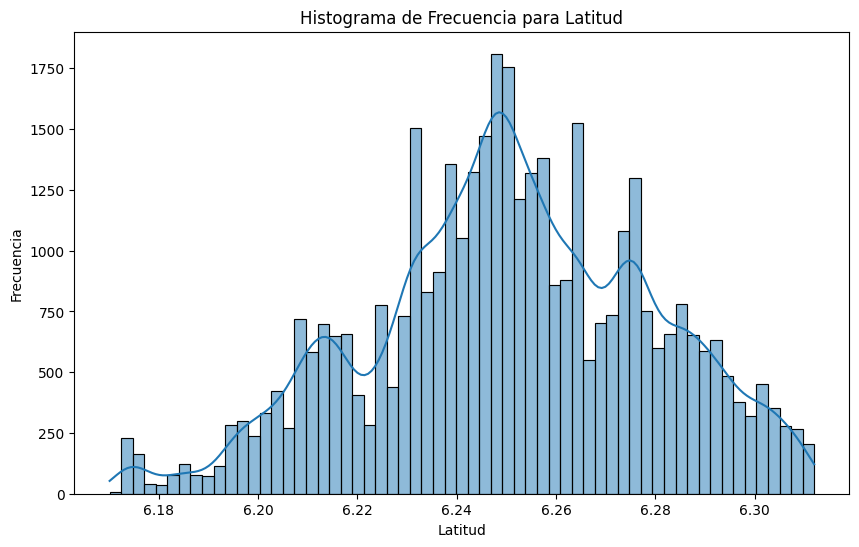

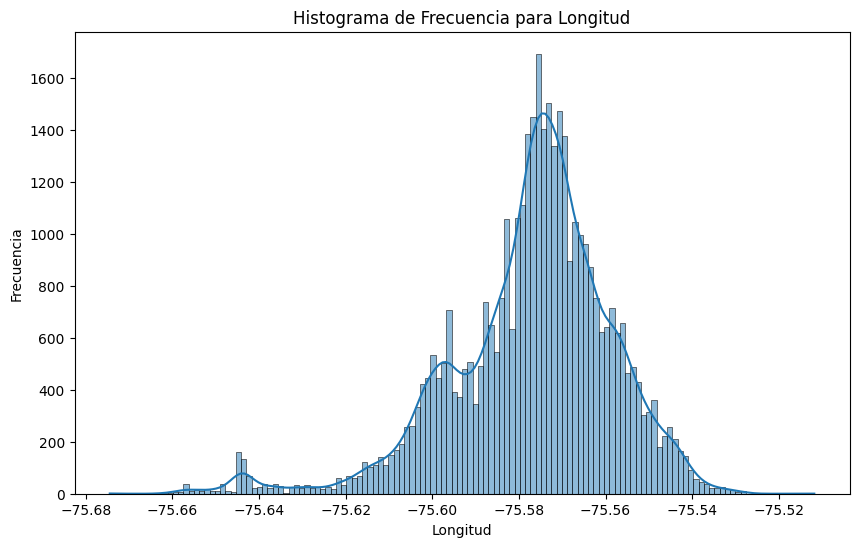

In [ ]:
for column in ['Latitud', 'Longitud']:
    # Check if the column is numerical before attempting to plot a histogram
    if pd.api.types.is_numeric_dtype(datos[column]):
        plt.figure(figsize=(10, 6))
        sns.histplot(datos[column], kde=True)
        plt.title(f'Histograma de Frecuencia para {column}')
        plt.xlabel(column)
        plt.ylabel('Frecuencia')
        plt.show()
    else:
        print(f"Skipping histogram for non-numeric column: {column}")

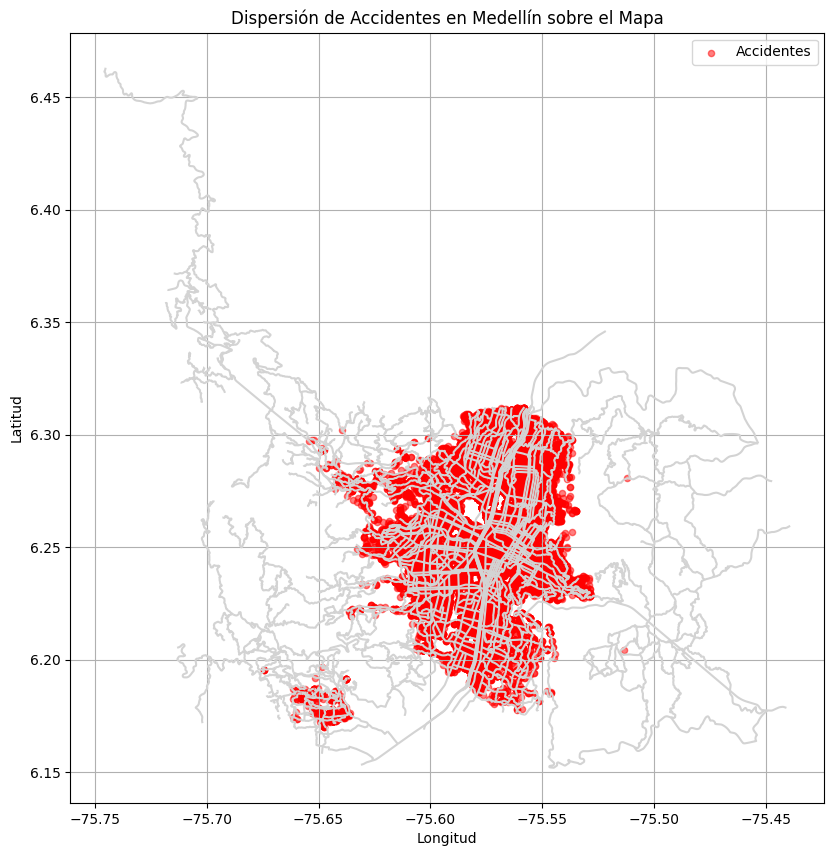

In [ ]:
# Load the Medellin shapefile
medellin_map = gpd.read_file('/content/vias_extracted/ViasUrbanoRural-07-20.shp')

# Convert accident data to a GeoDataFrame
geom = gpd.points_from_xy(datos['Longitud'], datos['Latitud'])
accidentes_gdf = gpd.GeoDataFrame(datos, geometry=geom, crs=medellin_map.crs)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot Medellin map
medellin_map.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot accident points with increased marker size
accidentes_gdf.plot(ax=ax, marker='o', color='red', markersize=20, alpha=0.5, label='Accidentes')

plt.title('Dispersión de Accidentes en Medellín sobre el Mapa')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend()
plt.grid(True)
plt.show()

###2. Variables seleccionadas y Escalado

In [ ]:
datos_modelo = datos[['Latitud','Longitud']]

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(datos_modelo)
scaled_features

array([[0.09948393, 1.28191182],
       [0.85871523, 0.91630799],
       [0.01457706, 1.63882206],
       ...,
       [1.14174468, 1.54204905],
       [0.5006327 , 1.36954084],
       [1.41781087, 0.04576397]])

###3. Modelos

In [ ]:
km = KMeans(
  init="random", # Este parámetro determina donde se ubican los centroides inicialmente
  n_clusters=16, # Corresponde al número de clusters que se van a crear
  n_init=10, # El número de veces que se iniciarán los centroides para seleccionar los mejores, según la inercia
  max_iter=500, # Número máximo de iteraciones para encontrar los clusters optimos
  random_state=42 # Este valor asegura que los resultados son reproducibles
  )
km.fit(scaled_features)

KMeans(init='random', max_iter=500, n_clusters=16, n_init=10, random_state=42)

In [ ]:
kmeans_labels = km.labels_
silhouette_avg = silhouette_score(scaled_features, kmeans_labels)
print("Kmeans Silhouette Score:", silhouette_avg)

Kmeans Silhouette Score: 0.37875918636280914


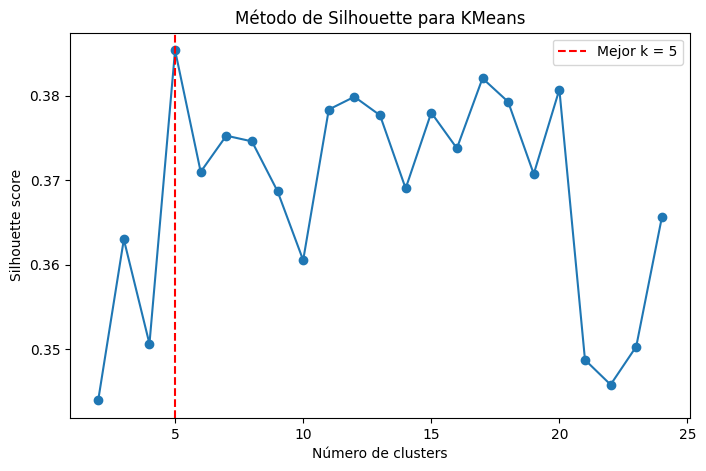

Resultados del Silhouette Score:
Clusters: 2  ->  Silhouette Score: 0.3439
Clusters: 3  ->  Silhouette Score: 0.3630
Clusters: 4  ->  Silhouette Score: 0.3506
Clusters: 5  ->  Silhouette Score: 0.3854
Clusters: 6  ->  Silhouette Score: 0.3710
Clusters: 7  ->  Silhouette Score: 0.3753
Clusters: 8  ->  Silhouette Score: 0.3746
Clusters: 9  ->  Silhouette Score: 0.3687
Clusters: 10  ->  Silhouette Score: 0.3605
Clusters: 11  ->  Silhouette Score: 0.3784
Clusters: 12  ->  Silhouette Score: 0.3799
Clusters: 13  ->  Silhouette Score: 0.3777
Clusters: 14  ->  Silhouette Score: 0.3690
Clusters: 15  ->  Silhouette Score: 0.3780
Clusters: 16  ->  Silhouette Score: 0.3738
Clusters: 17  ->  Silhouette Score: 0.3821
Clusters: 18  ->  Silhouette Score: 0.3793
Clusters: 19  ->  Silhouette Score: 0.3707
Clusters: 20  ->  Silhouette Score: 0.3807
Clusters: 21  ->  Silhouette Score: 0.3487
Clusters: 22  ->  Silhouette Score: 0.3458
Clusters: 23  ->  Silhouette Score: 0.3503
Clusters: 24  ->  Silhouette 

In [ ]:
silueta_km = []

n_cluster = range(2,25)

for i in n_cluster:

  kmeans = KMeans(n_clusters=i, random_state=42)

  kmeans.fit(scaled_features)

  score = silhouette_score(
      scaled_features,
      kmeans.labels_,
      sample_size=5000,
      random_state=42
  )

  silueta_km.append(score)

# encontrar el mejor cluster
best_score = max(silueta_km)
best_k = list(n_cluster)[silueta_km.index(best_score)]

# grafico
plt.figure(figsize=(8,5))
plt.plot(list(n_cluster), silueta_km, marker='o')
plt.axvline(x=best_k, color='red', linestyle='--', label=f"Mejor k = {best_k}")

plt.xlabel("Número de clusters")
plt.ylabel("Silhouette score")
plt.title("Método de Silhouette para KMeans")
plt.legend()

plt.show()

# imprimir resultados
print("Resultados del Silhouette Score:")
for i, score in zip(n_cluster, silueta_km):
    print(f"Clusters: {i}  ->  Silhouette Score: {score:.4f}")

print("\nMejor número de clusters:", best_k)
print("Mejor Silhouette Score:", round(best_score,4))

In [ ]:
dbs = DBSCAN(eps=0.3, min_samples=50)
dbs.fit(scaled_features)

DBSCAN(eps=0.3, min_samples=50)

In [ ]:
dbscan_labels = dbs.labels_
silhouette_avg = silhouette_score(scaled_features, dbscan_labels)
print("DBSCAN Silhouette Score:", silhouette_avg)

DBSCAN Silhouette Score: 0.5194673555431971


In [ ]:
labels = dbs.labels_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Número de clusters DBSCAN:", n_clusters)
n_noise = list(labels).count(-1)

print("Puntos de ruido:", n_noise)

Número de clusters DBSCAN: 2
Puntos de ruido: 61


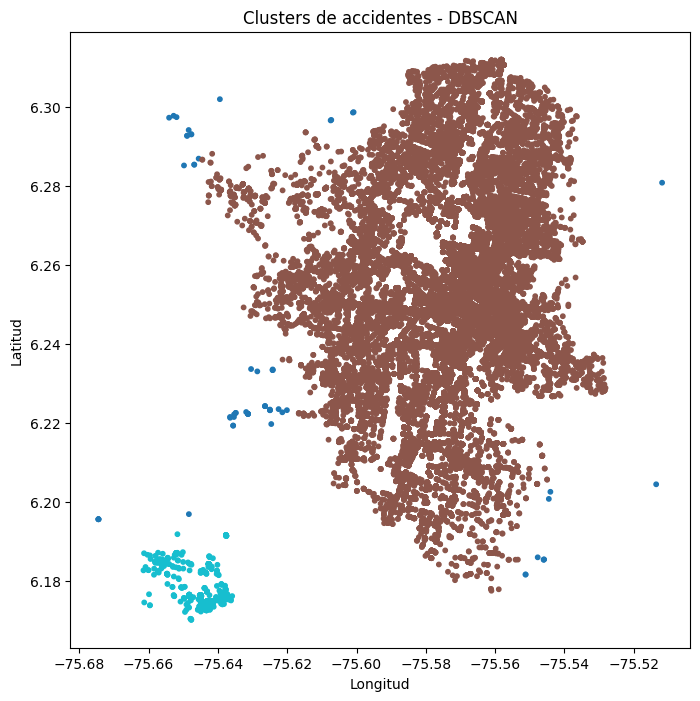

In [ ]:
import matplotlib.pyplot as plt

# agregar los clusters al dataset
datos["cluster"] = dbs.labels_

plt.figure(figsize=(8,8))

plt.scatter(
    datos["Longitud"],
    datos["Latitud"],
    c=datos["cluster"],
    cmap="tab10",
    s=10
)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Clusters de accidentes - DBSCAN")

plt.show()

In [ ]:
from sklearn.utils import resample

# tomar una muestra de 3000 puntos
sample = resample(scaled_features, n_samples=3000, random_state=42)

jerarquico = AgglomerativeClustering(n_clusters=22)

jerarquico.fit(sample)

print("Número de clusters jerárquicos:", len(set(jerarquico.labels_)))
silhouette_jerarquico = silhouette_score(sample, jerarquico.labels_)

print("Jerárquico Silhouette Score:", silhouette_jerarquico)

Número de clusters jerárquicos: 22
Jerárquico Silhouette Score: 0.34021750313973675


In [ ]:
datos['kmeans_cluster'] = kmeans_labels
display(datos.head())

,NRO_RADICADO,Latitud,Longitud,CLASE_ACCIDENTE,DIRECCION,Gravedad Incidente,nombre comuna,Barrio,Diseño,Año,FECHA_ACCIDENTE,HORA_ACCIDENTE,codigo comuna,Comuna,cluster,kmeans_cluster
0,1611599,6.253440,-75.552931,Caida Ocupante,CR 37 CL 63,Con heridos,Villa Hermosa,La Ladera,Tramo de via,2018,2018-01-01,00:10:00,8,08 - Villa Hermosa,0,0
1,1611540,6.275106,-75.559833,Choque,CR 50 B CL 81 A,Con heridos,Aranjuez,Brasilia,Interseccion,2018,2018-01-01,00:20:00,4,04 - Aranjuez,0,0
2,1611518,6.251017,-75.546193,Otro,CL 58 CR 25,Con heridos,Villa Hermosa,Los Mangos,Lote o Predio,2018,2018-01-01,00:20:00,8,08 - Villa Hermosa,0,11
3,1611589,6.264690,-75.568750,Choque,CL 67 CR 55 AB,Con heridos,Aranjuez,Universidad de Antioquia,Tramo de via,2018,2018-01-01,01:20:00,4,04 - Aranjuez,0,4
4,1611605,6.264725,-75.545761,Choque,CL 70 CR 33,Con heridos,Manrique,Versalles No. 1,Tramo de via,2018,2018-01-01,01:30:00,3,03 - Manrique,0,0


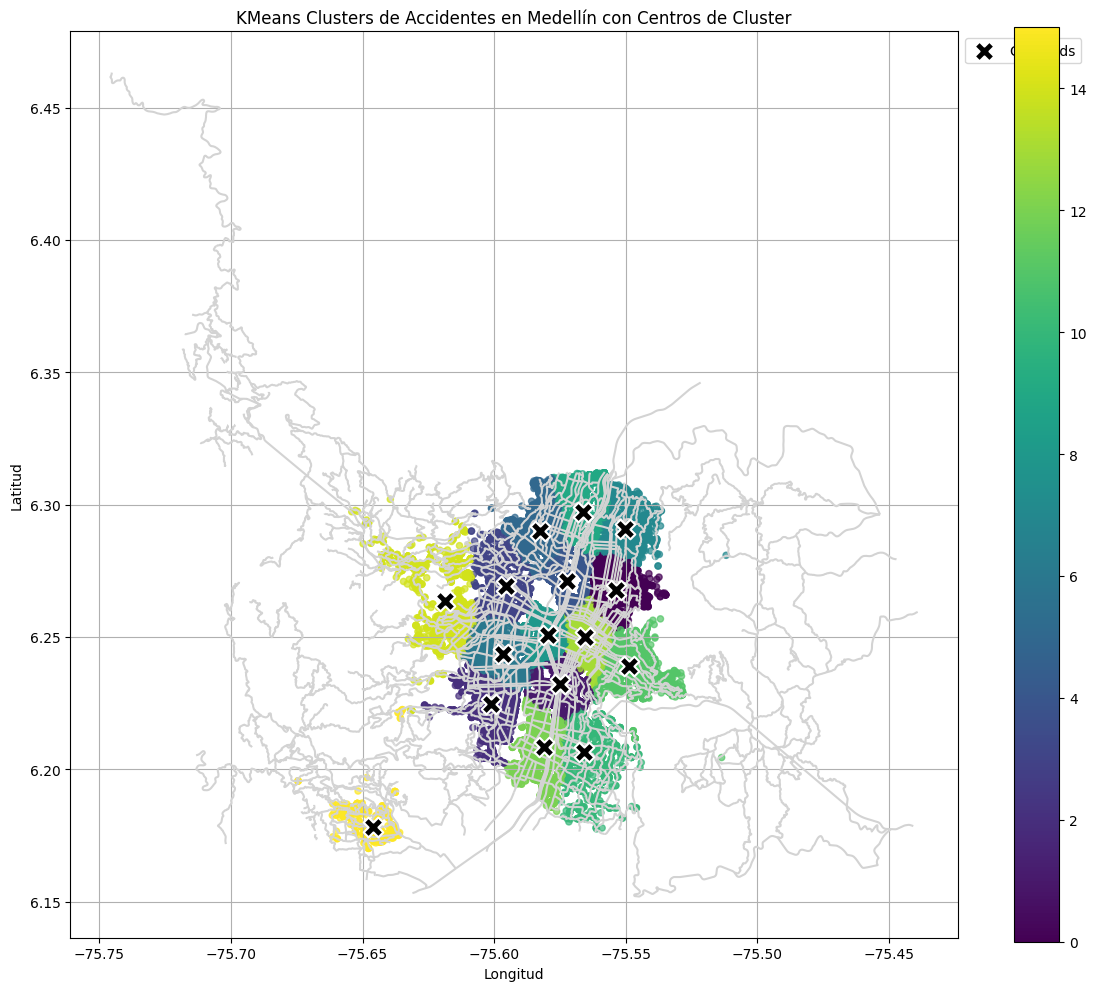

In [ ]:
medellin_map = gpd.read_file('/content/vias_extracted/ViasUrbanoRural-07-20.shp')

geom_kmeans = gpd.points_from_xy(datos['Longitud'], datos['Latitud'])
accidentes_kmeans_gdf = gpd.GeoDataFrame(datos, geometry=geom_kmeans, crs=medellin_map.crs)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

medellin_map.plot(ax=ax, color='lightgray', edgecolor='black')

accidentes_kmeans_gdf.plot(ax=ax, column='kmeans_cluster', cmap='viridis', markersize=20, legend=True, alpha=0.7)

# Get KMeans centroids and inverse transform them
centroids = scaler.inverse_transform(km.cluster_centers_)
centroids_gdf = gpd.GeoDataFrame(
    {'cluster': range(len(centroids))},
    geometry=gpd.points_from_xy(centroids[:, 1], centroids[:, 0]),
    crs=medellin_map.crs
)

# Plot centroids
centroids_gdf.plot(ax=ax, marker='X', color='black', markersize=200, edgecolor='white', linewidth=1.5, label='Centroids', zorder=2)

plt.title('KMeans Clusters de Accidentes en Medellín con Centros de Cluster')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### 4. Caracterizacion y analisis de los cluster



Total accidents per KMeans cluster:
kmeans_cluster
0     2015
1     3750
2     1818
3     2543
4     3524
5     1970
6     2585
7     1490
8     3723
9     2606
10    1911
11    1812
12    3381
13    4650
14    1257
15     630
Name: count, dtype: int64


/tmp/ipykernel_526/815584198.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accidents_per_kmeans_cluster.index, y=accidents_per_kmeans_cluster.values, palette='viridis')


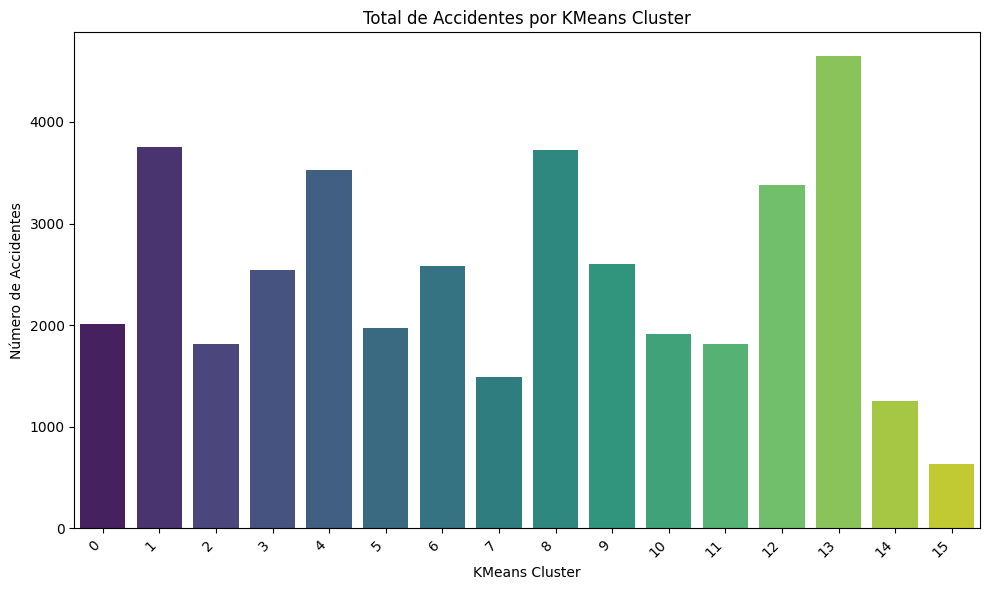

In [ ]:
accidents_per_kmeans_cluster = datos['kmeans_cluster'].value_counts().sort_index()
print("Total accidents per KMeans cluster:")
print(accidents_per_kmeans_cluster)

plt.figure(figsize=(10, 6))
sns.barplot(x=accidents_per_kmeans_cluster.index, y=accidents_per_kmeans_cluster.values, palette='viridis')
plt.title('Total de Accidentes por KMeans Cluster')
plt.xlabel('KMeans Cluster')
plt.ylabel('Número de Accidentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
print('Number of unique communes per KMeans cluster:')
unique_communes_count = datos.groupby('kmeans_cluster')['Comuna'].nunique()
print(unique_communes_count)

print('\nList of unique communes per KMeans cluster:')
unique_communes_list = datos.groupby('kmeans_cluster')['Comuna'].unique()
for cluster_id, communes in unique_communes_list.items():
    print(f'Cluster {cluster_id}: {list(communes)}')


Number of unique communes per KMeans cluster:
kmeans_cluster
0     5
1     6
2     4
3     5
4     4
5     4
6     3
7     5
8     4
9     4
10    3
11    4
12    2
13    4
14    6
15    2
Name: Comuna, dtype: int64

List of unique communes per KMeans cluster:
Cluster 0: ['08 - Villa Hermosa', '04 - Aranjuez', '03 - Manrique', '10 - La Candelaria', '90 - Corregimiento de Santa Elena']
Cluster 1: ['10 - La Candelaria', '15 - Guayabal', '14 - El Poblado', '11 - Laureles Estadio', '16 - Belén', '09 - Buenos Aires']
Cluster 2: ['16 - Belén', '70 - Corregimiento de Altavista', '11 - Laureles Estadio', '15 - Guayabal']
Cluster 3: ['12 - La América', '07 - Robledo', '11 - Laureles Estadio', '13 - San Javier', '60 - Corregimiento de San Cristóbal']
Cluster 4: ['04 - Aranjuez', '10 - La Candelaria', '05 - Castilla', '07 - Robledo']
Cluster 5: ['07 - Robledo', '06 - Doce de Octubre', '05 - Castilla', '60 - Corregimiento de San Cristóbal']
Cluster 6: ['11 - Laureles Estadio', '16 - Belén', '12 - 

In [ ]:
print('Number of unique barrios per KMeans cluster:')
unique_barrios_count = datos.groupby('kmeans_cluster')['Barrio'].nunique()
print(unique_barrios_count)

print('\nList of unique barrios per KMeans cluster:')
unique_barrios_list = datos.groupby('kmeans_cluster')['Barrio'].unique()
for cluster_id, barrios in unique_barrios_list.items():
    print(f'Cluster {cluster_id}: {list(barrios)}')


Number of unique barrios per KMeans cluster:
kmeans_cluster
0     32
1     21
2     27
3     36
4     24
5     28
6     28
7     39
8     23
9     28
10    26
11    40
12    18
13    26
14    46
15    10
Name: Barrio, dtype: int64

List of unique barrios per KMeans cluster:
Cluster 0: ['La Ladera', 'Brasilia', 'Versalles No. 1', 'Campo Valdés No. 2', 'Las Granjas', 'Campo Valdés No. 1', 'Miranda', 'El Raizal', 'San Pedro', 'Manrique Oriental', 'Manrique Central No. 2', 'Villa Hermosa', 'Las Esmeraldas', 'Santa Inés', 'Manrique Central No. 1', 'San Miguel', 'La Mansión', 'Aranjuez', 'El Pomar', 'La Piñuela', 'Oriente', 'Manrique Central No.2', 'Versalles No. 2', 'Campo Valdés No.2', 'Prado', 'Jardín Botánico', 'Sevilla', 'Piedras Blancas', 'Batallón Girardot', 'La Cruz', 'Manrique Central No.1', 'Versalles No.1']
Cluster 1: ['Perpetuo Socorro', 'San Diego', 'Calle Nueva', 'Tenche', 'Villa Carlota', 'Trinidad', 'Centro Administrativo', 'Barrio Colón', 'Los Conquistadores', 'Barrio Colomb

/tmp/ipykernel_526/2972530288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')


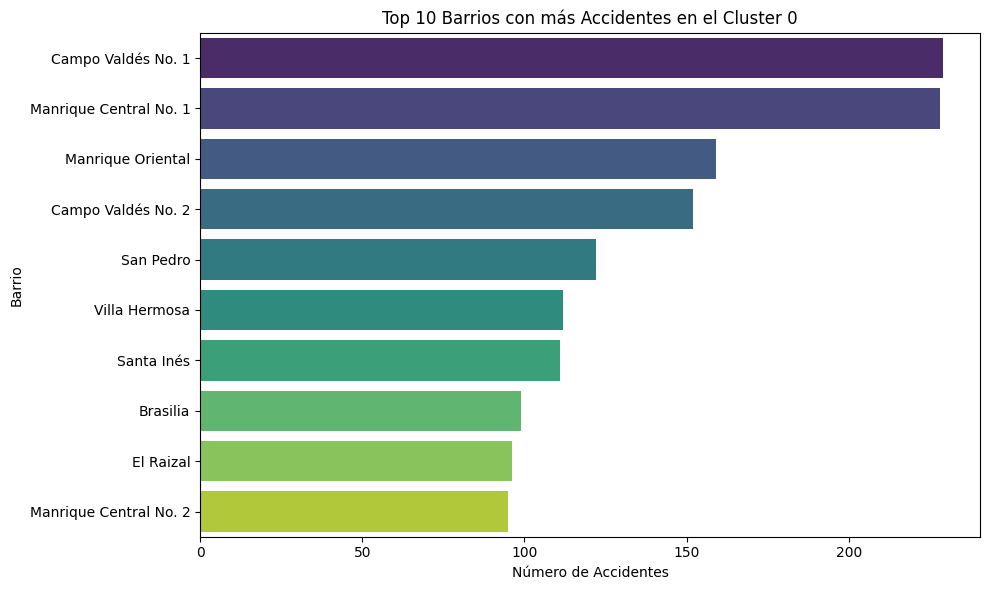

/tmp/ipykernel_526/2972530288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')


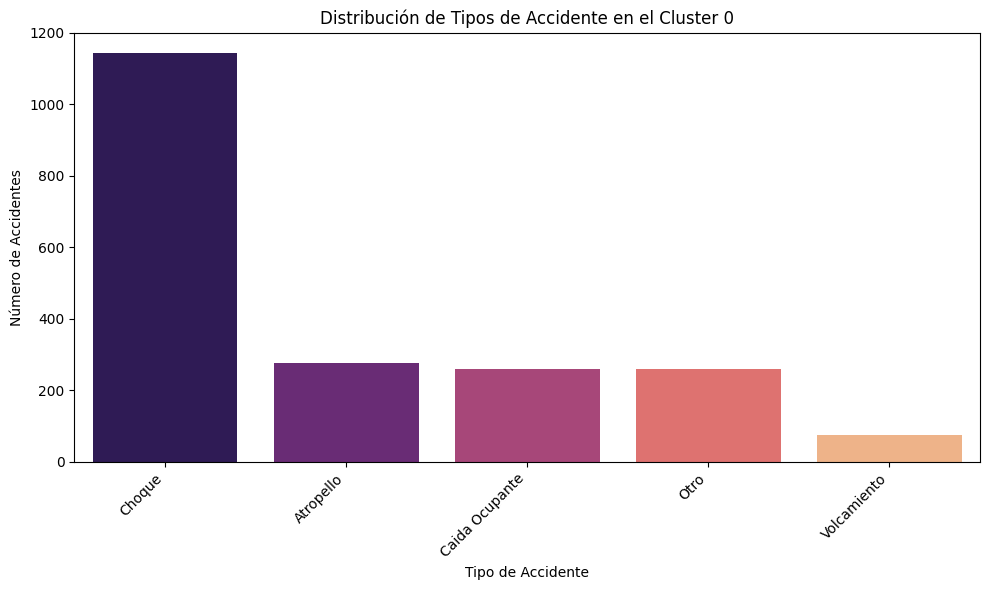

/tmp/ipykernel_526/2972530288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')


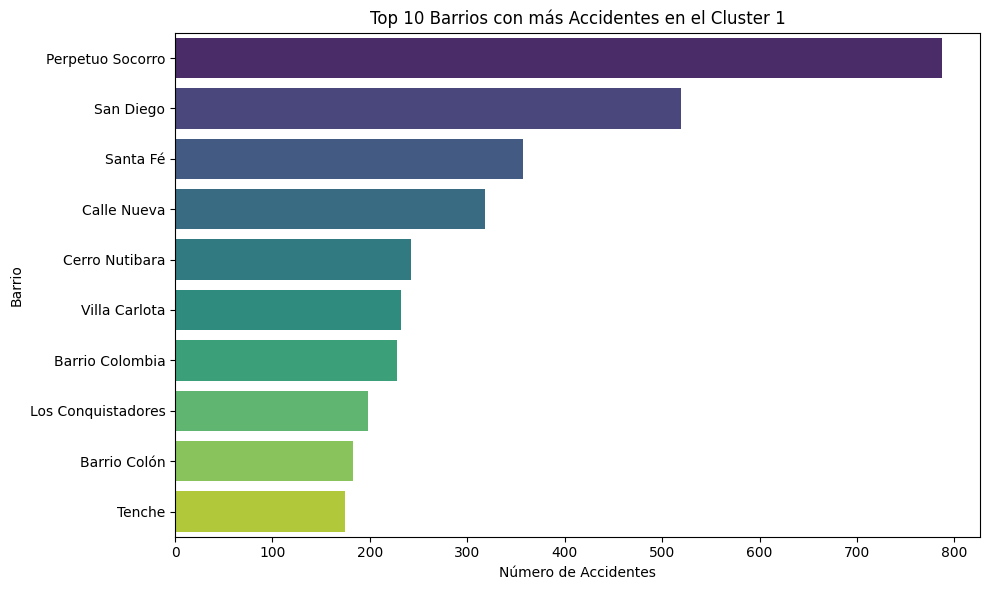

/tmp/ipykernel_526/2972530288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')


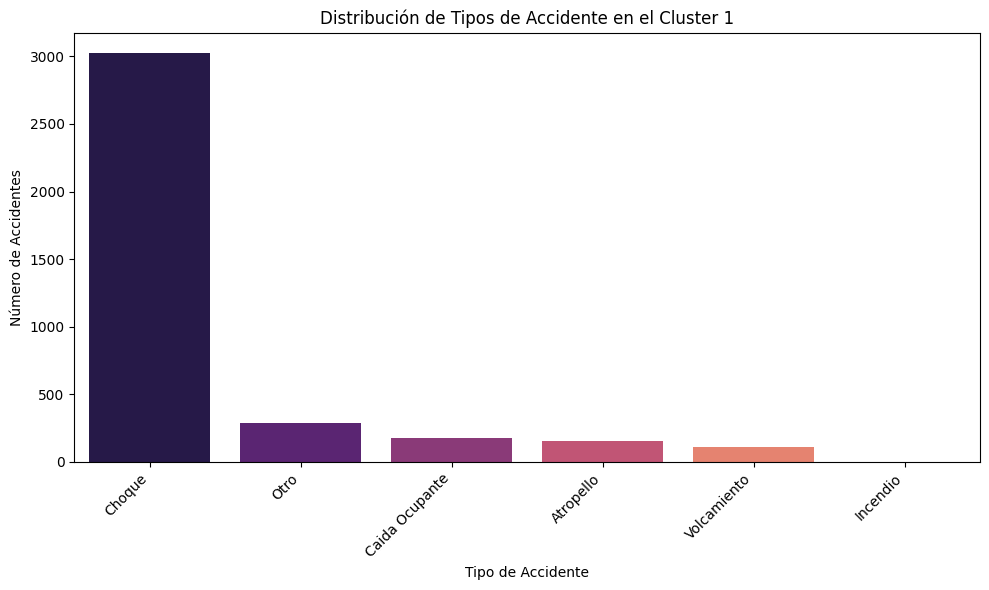

/tmp/ipykernel_526/2972530288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')


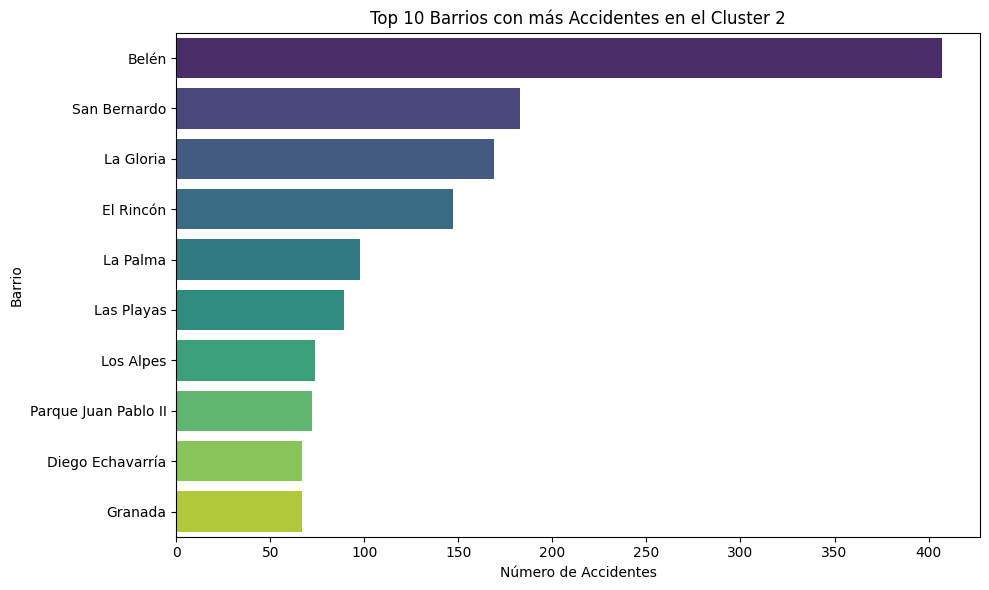

/tmp/ipykernel_526/2972530288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')


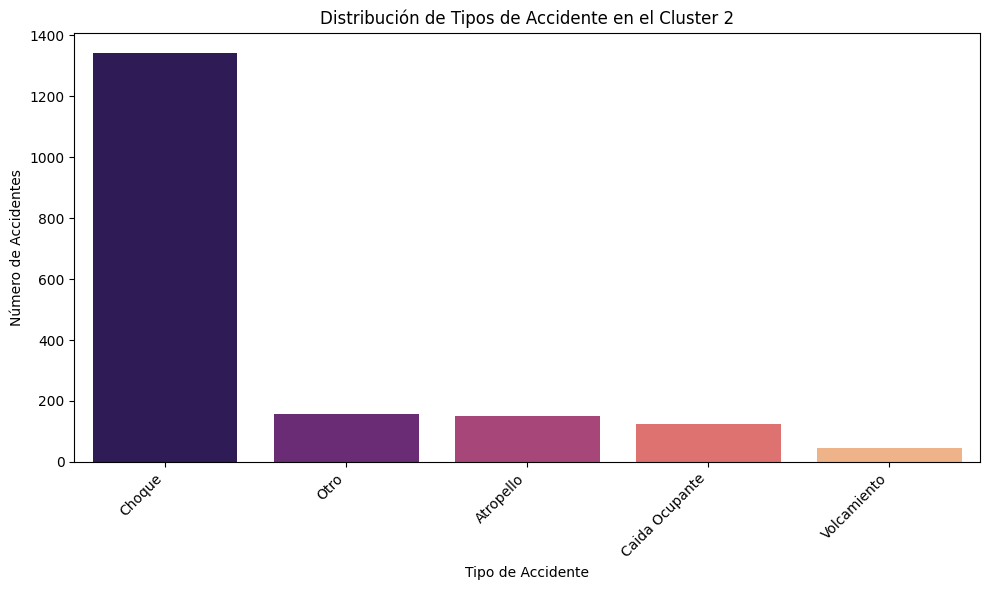

/tmp/ipykernel_526/2972530288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')


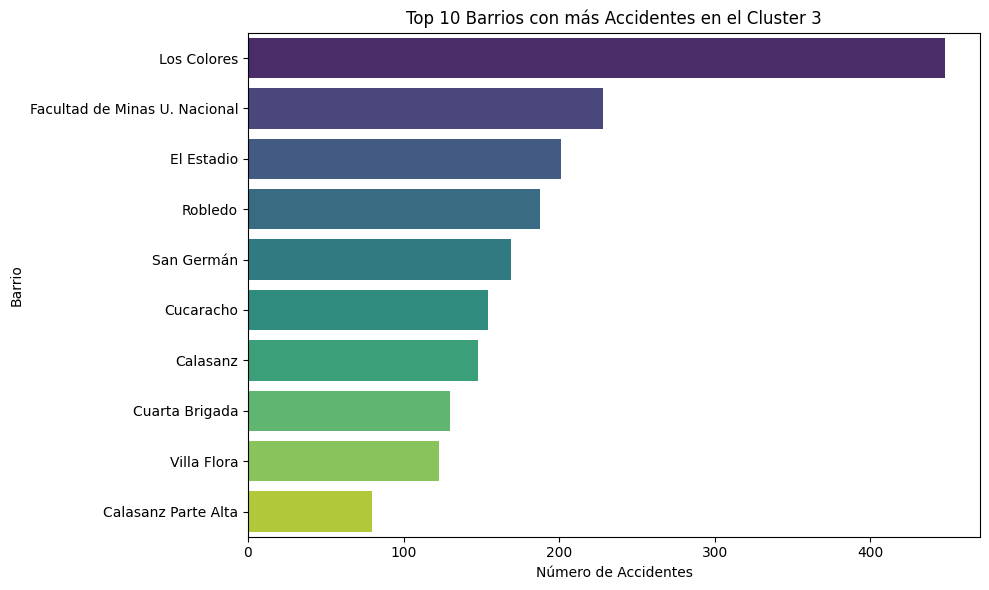

/tmp/ipykernel_526/2972530288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')


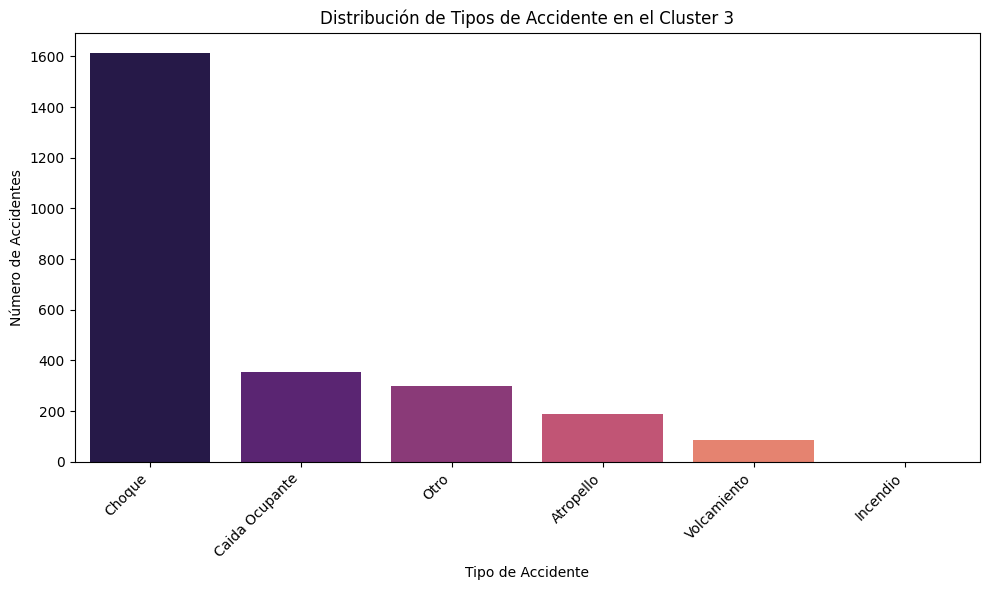

/tmp/ipykernel_526/2972530288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')


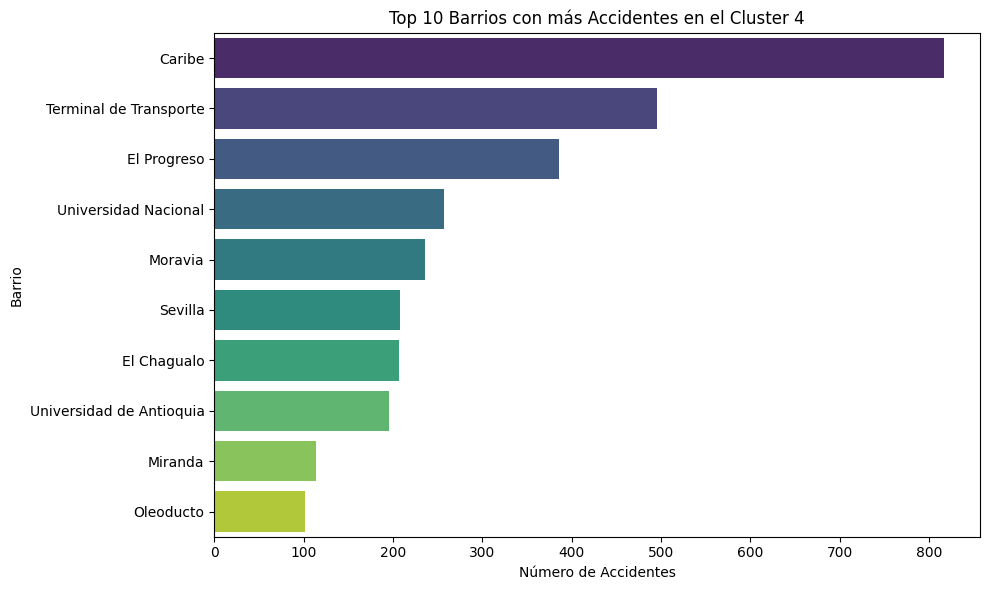

/tmp/ipykernel_526/2972530288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')


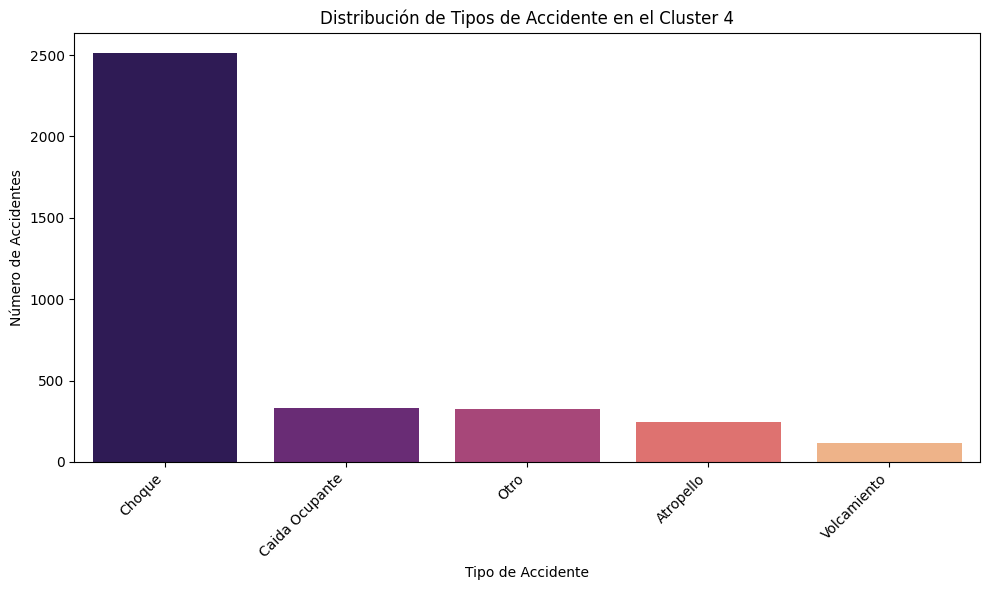

/tmp/ipykernel_526/2972530288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')


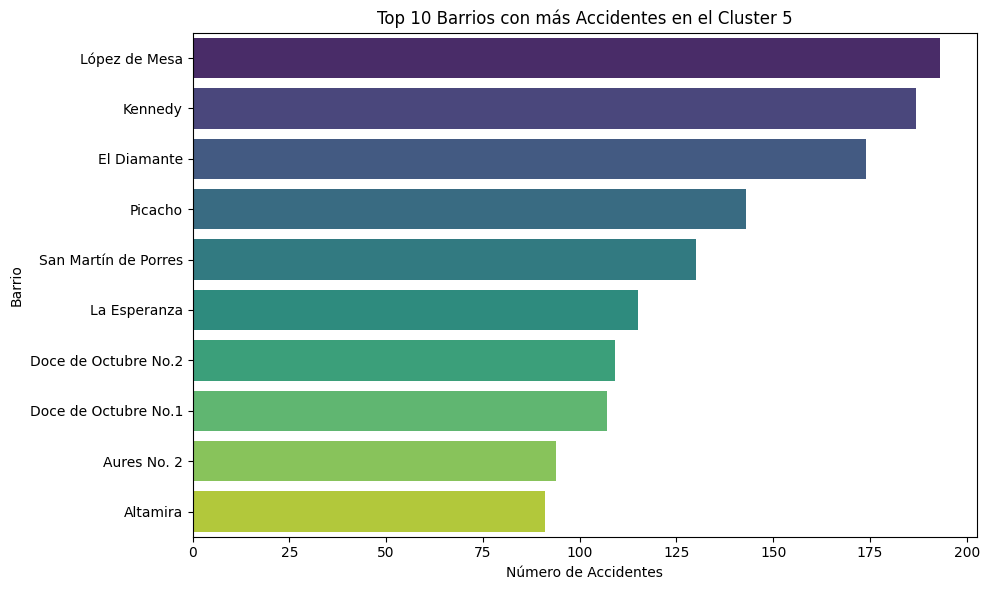

/tmp/ipykernel_526/2972530288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')


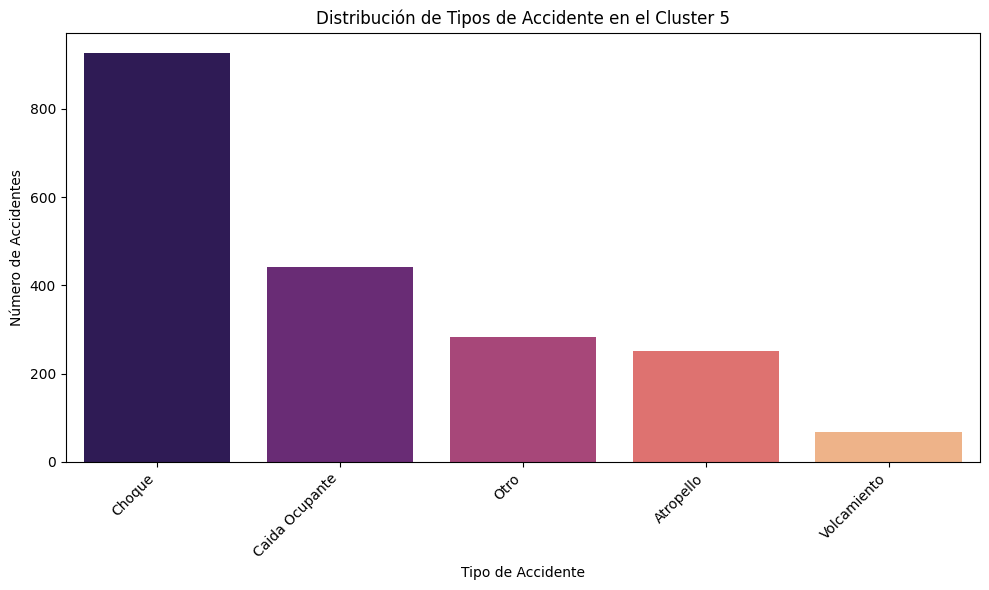

/tmp/ipykernel_526/2972530288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')


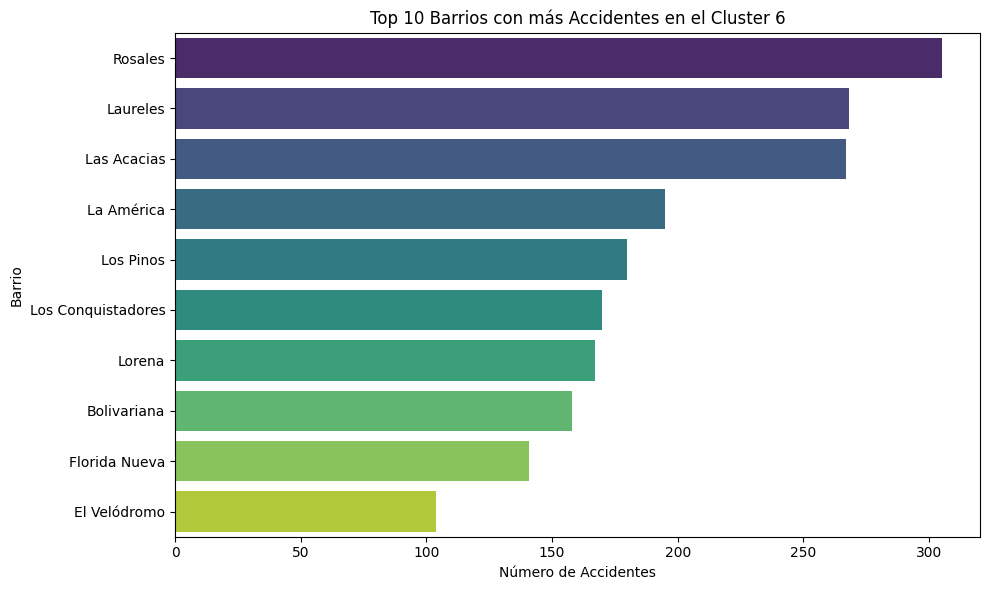

/tmp/ipykernel_526/2972530288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')


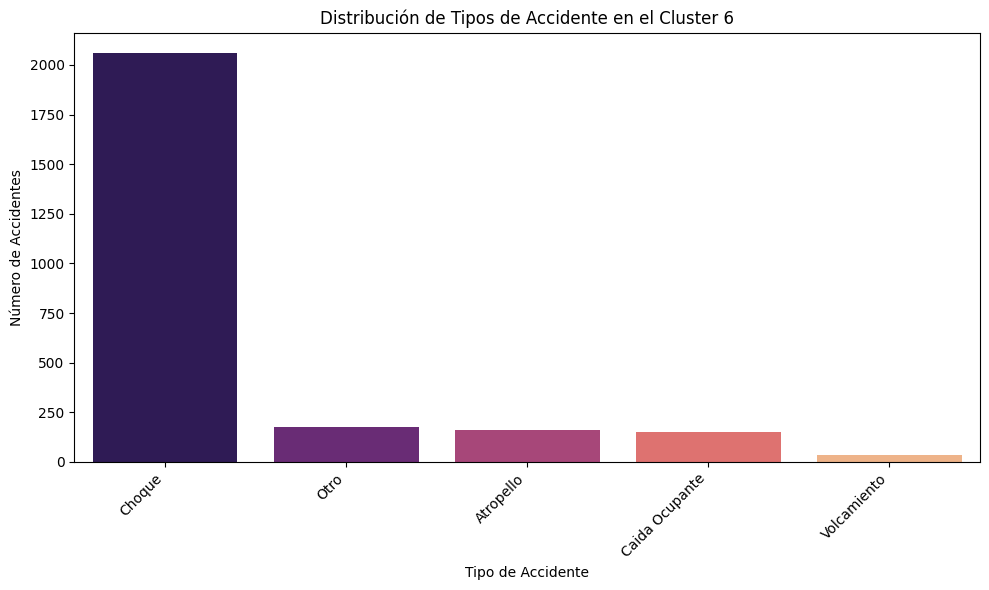

/tmp/ipykernel_526/2972530288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')


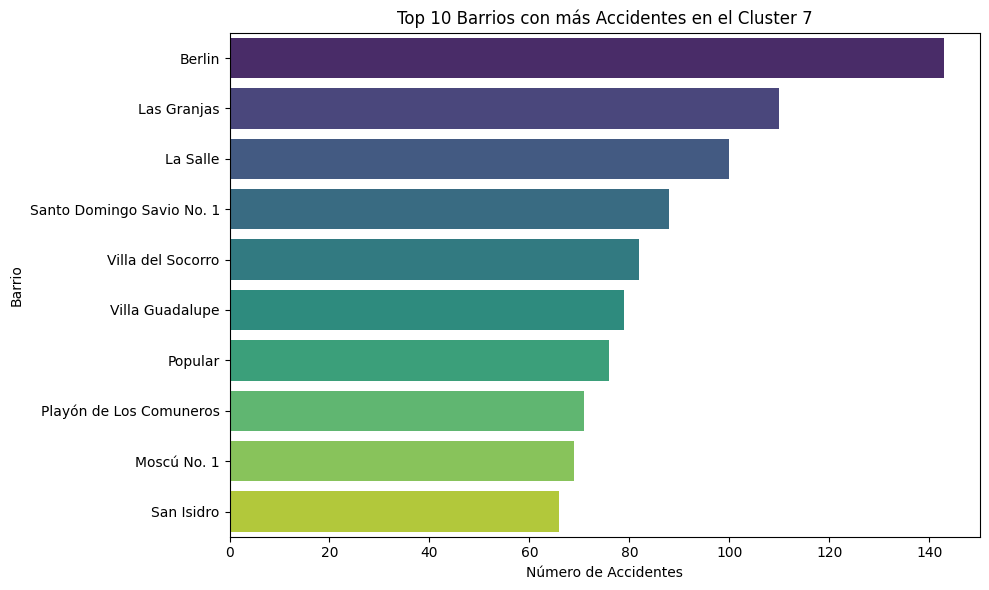

/tmp/ipykernel_526/2972530288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')


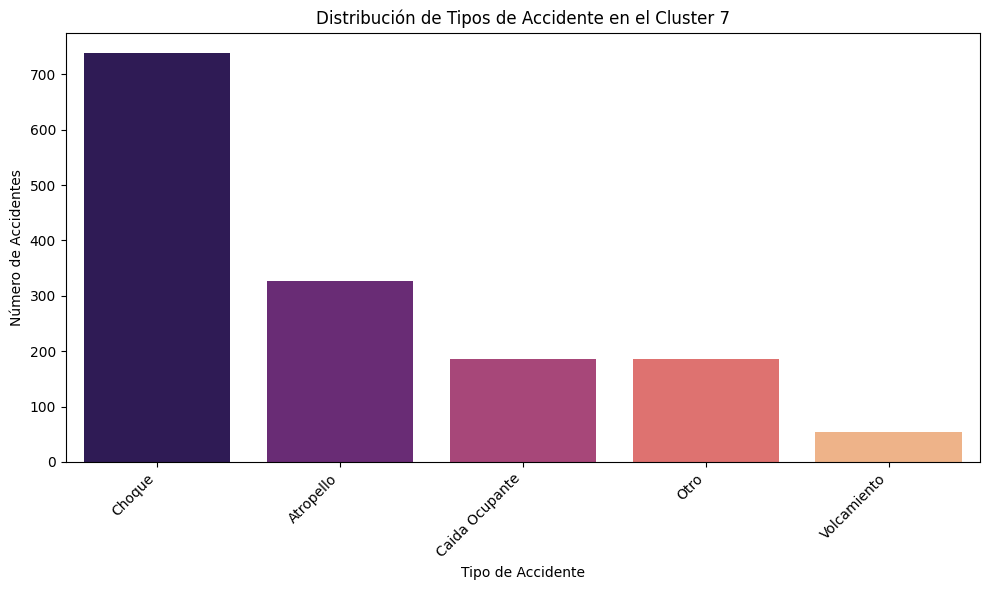

/tmp/ipykernel_526/2972530288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')


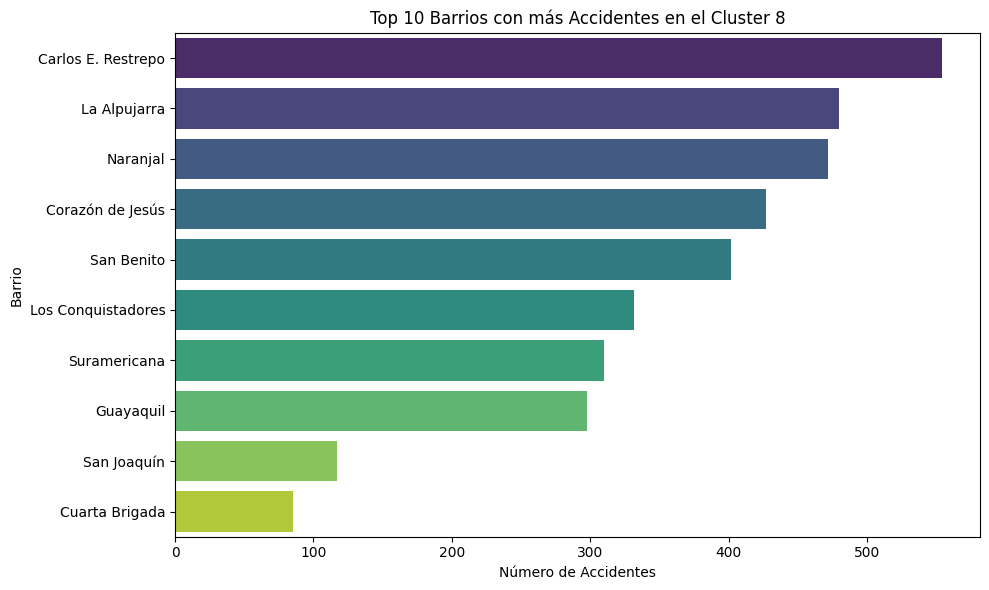

/tmp/ipykernel_526/2972530288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')


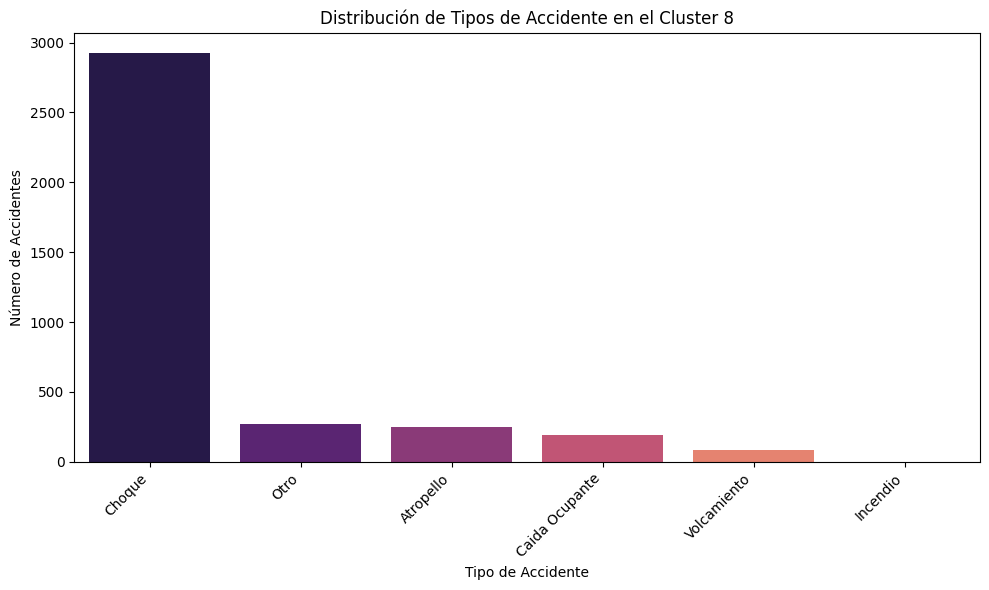

/tmp/ipykernel_526/2972530288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')


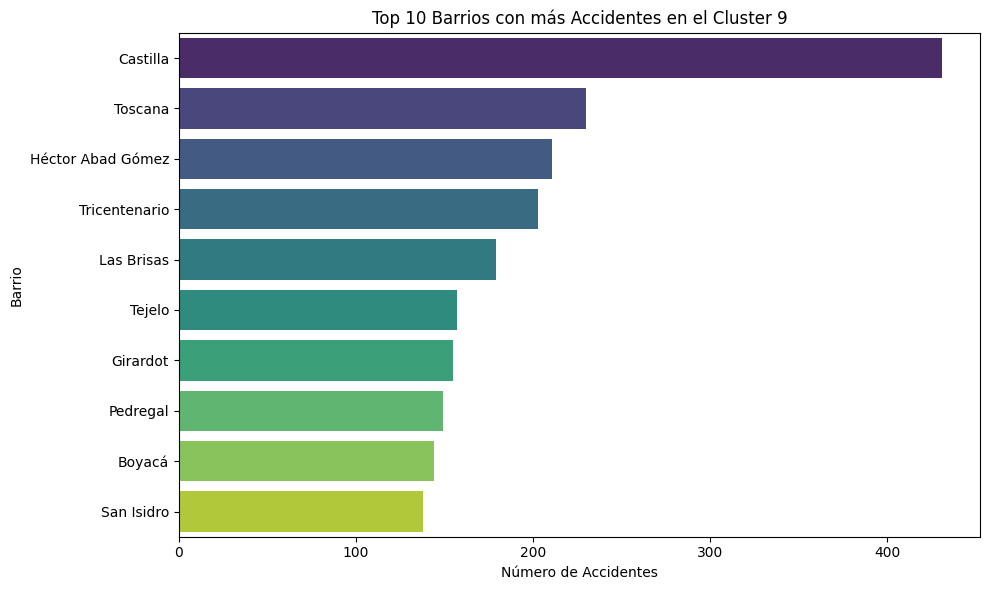

/tmp/ipykernel_526/2972530288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')


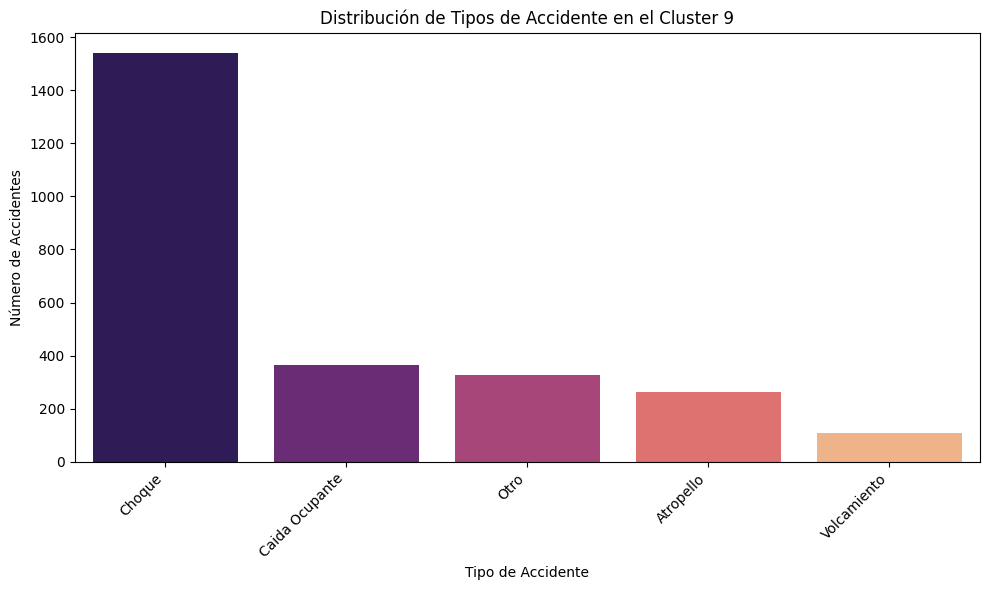

/tmp/ipykernel_526/2972530288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')


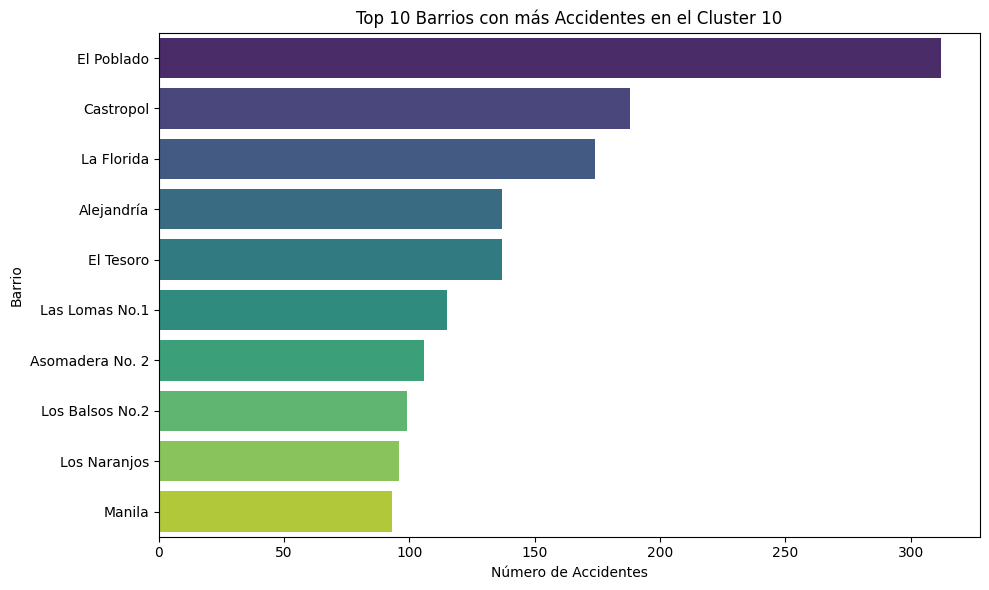

/tmp/ipykernel_526/2972530288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')


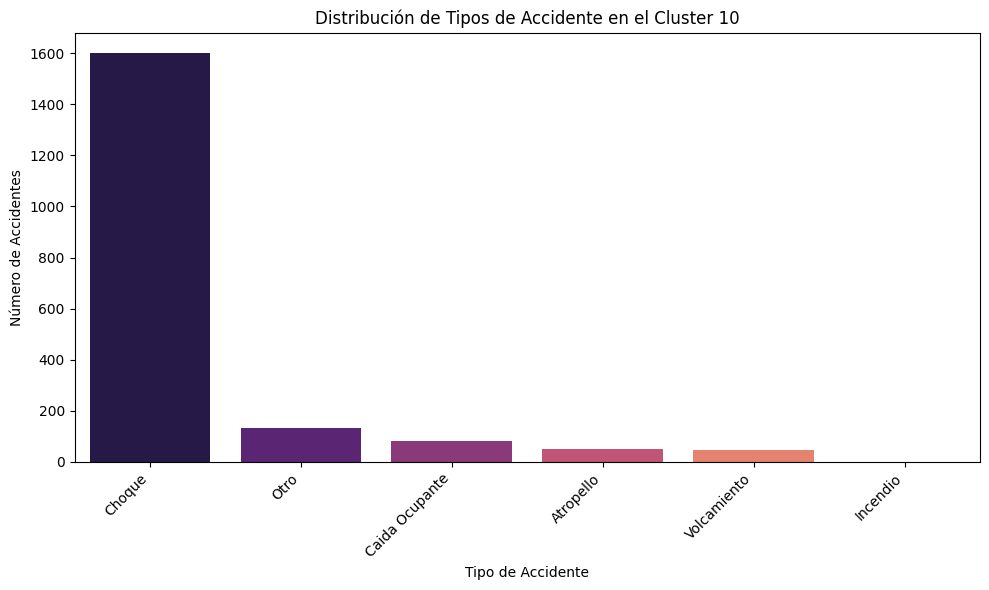

/tmp/ipykernel_526/2972530288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')


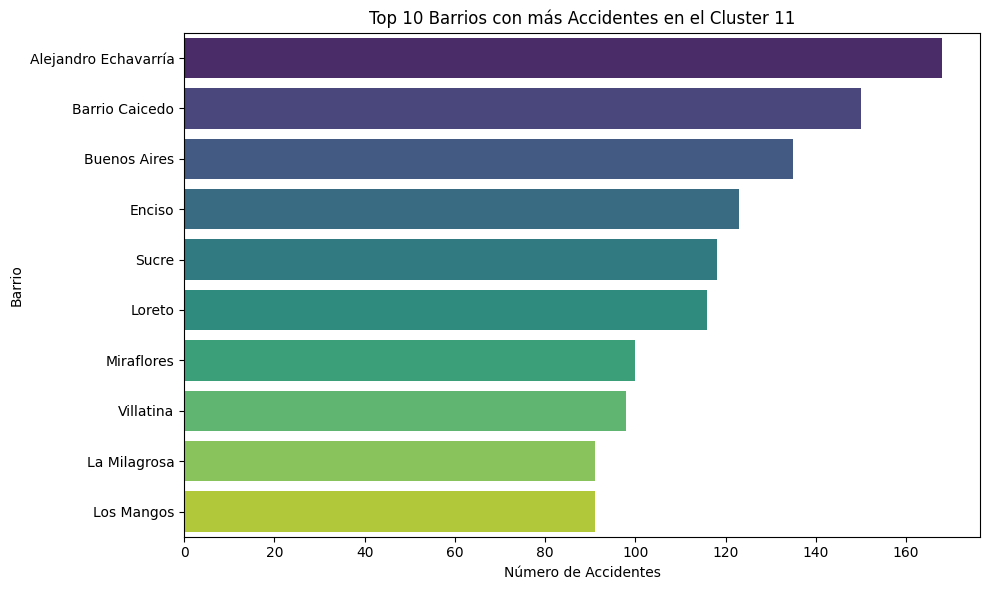

/tmp/ipykernel_526/2972530288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')


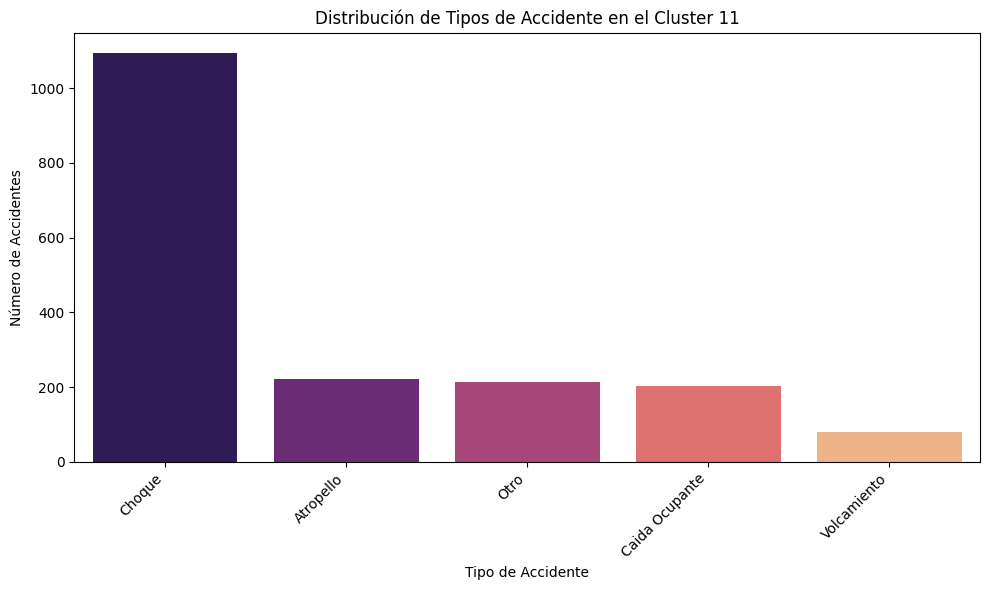

/tmp/ipykernel_526/2972530288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')


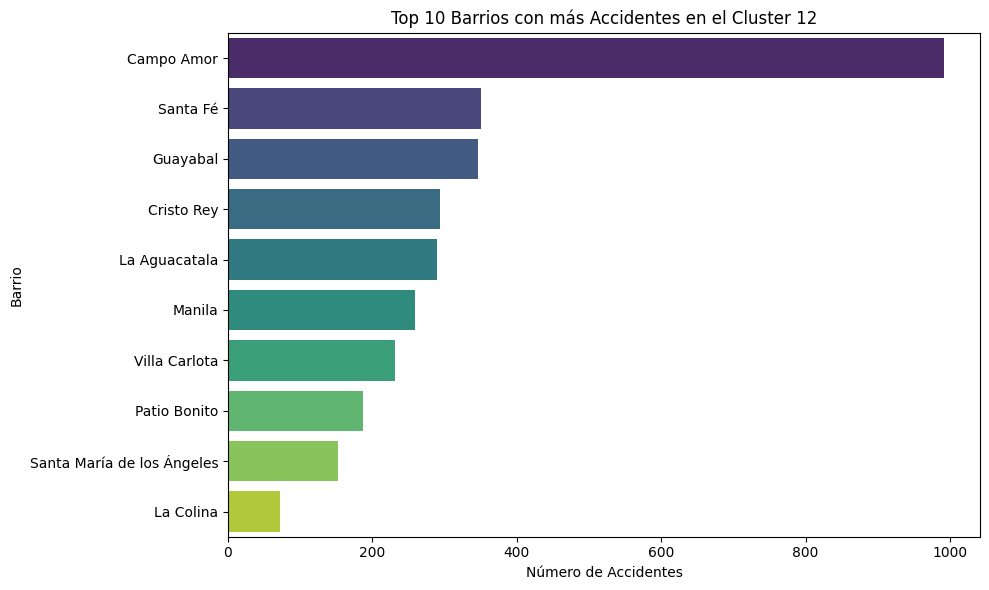

/tmp/ipykernel_526/2972530288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')


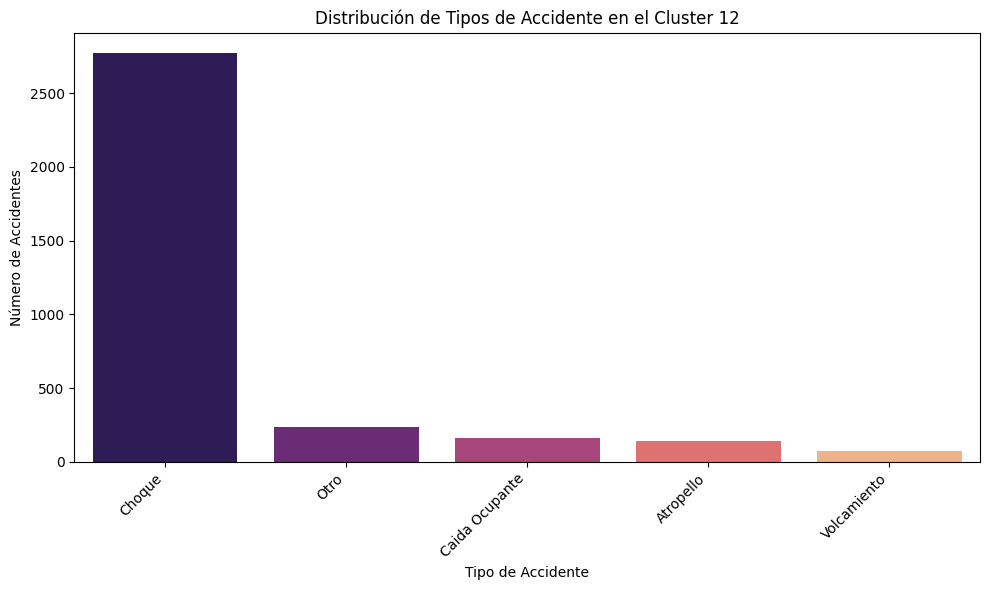

/tmp/ipykernel_526/2972530288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')


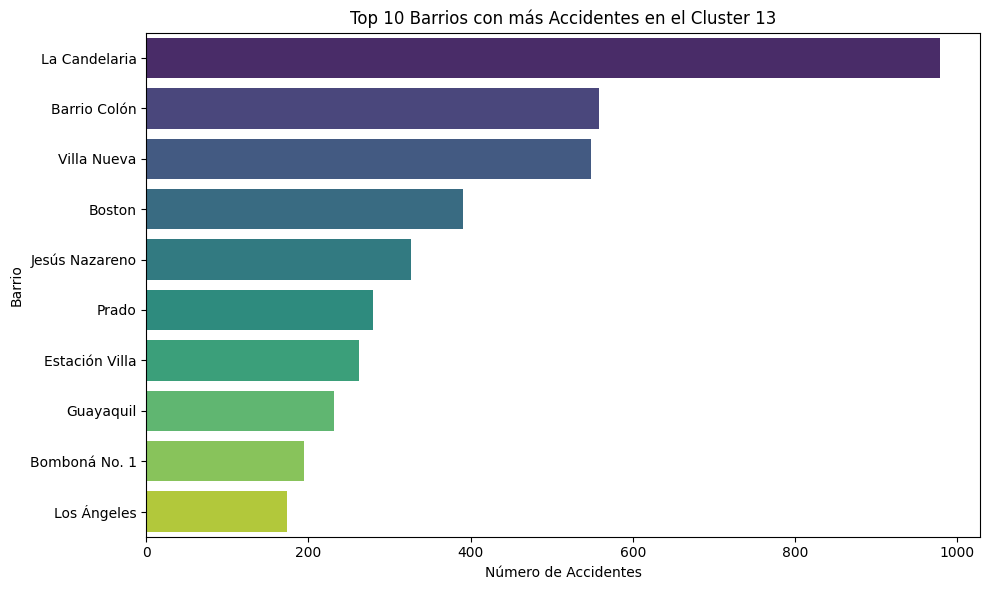

/tmp/ipykernel_526/2972530288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')


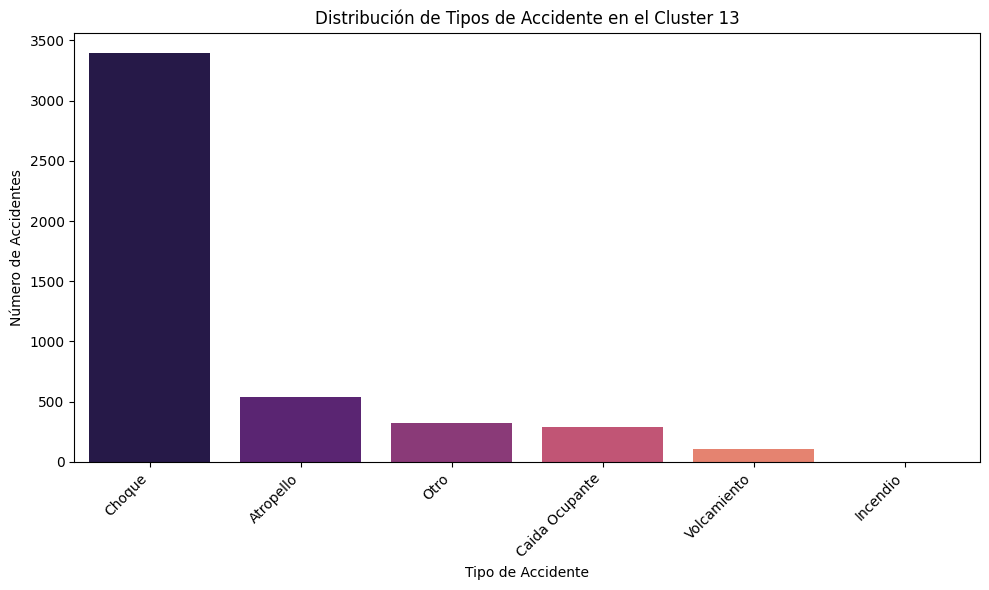

/tmp/ipykernel_526/2972530288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')


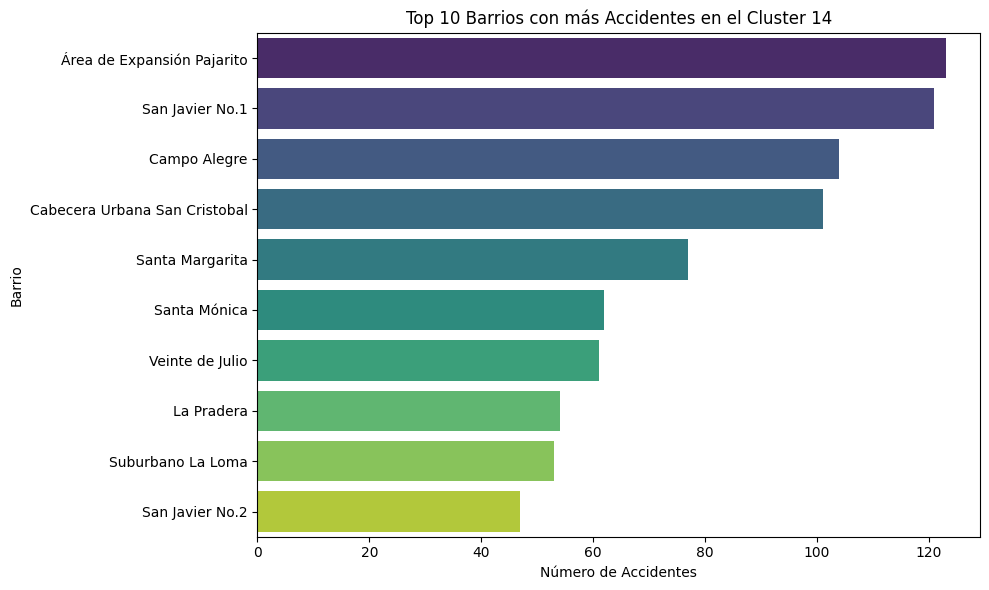

/tmp/ipykernel_526/2972530288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')


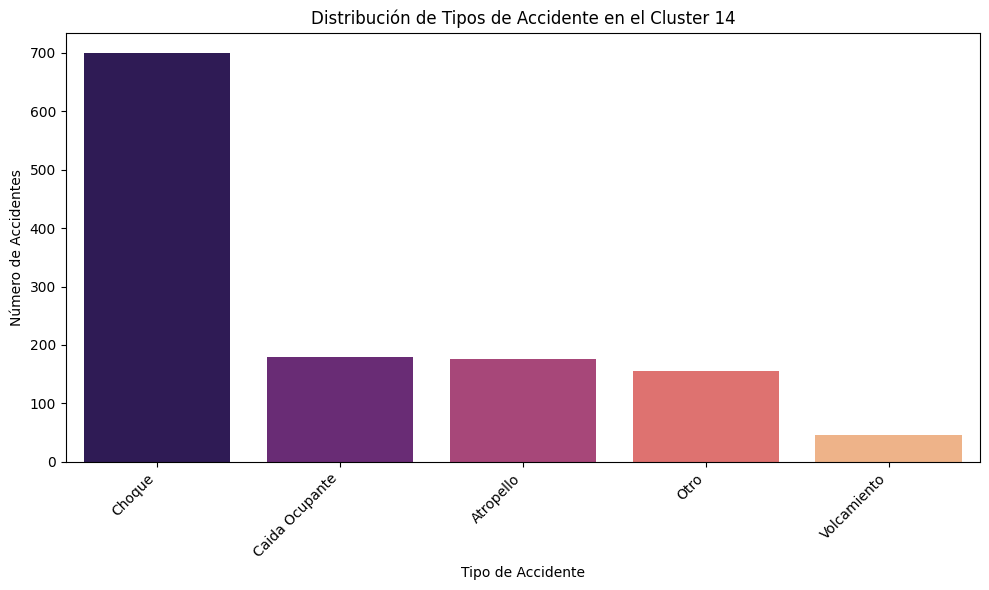

/tmp/ipykernel_526/2972530288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')


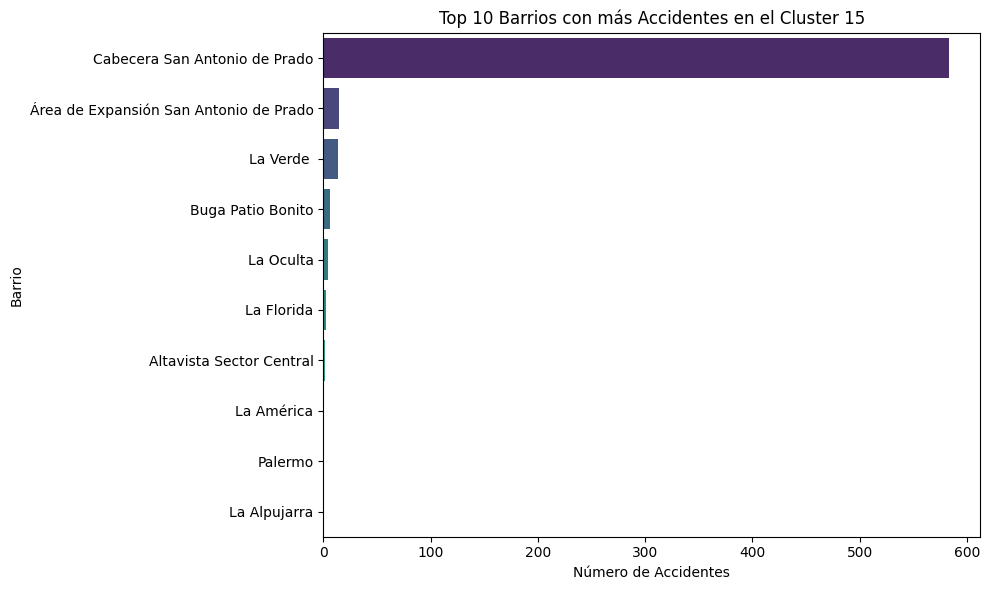

/tmp/ipykernel_526/2972530288.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')


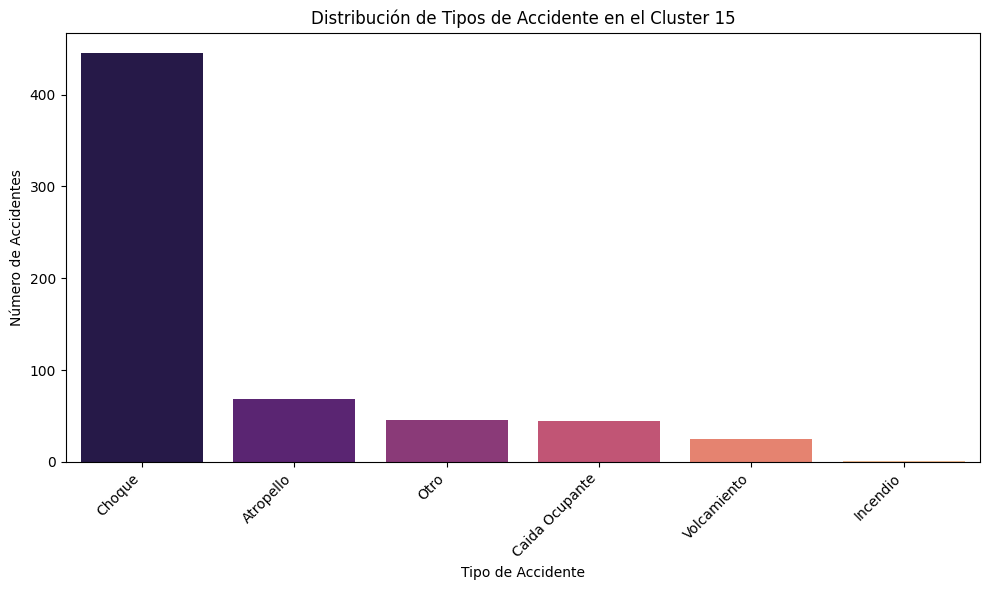

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_clusters = datos['kmeans_cluster'].unique()
unique_clusters.sort()

for cluster_id in unique_clusters:
    cluster_data = datos[datos['kmeans_cluster'] == cluster_id]

    # Plot for Top Barrios by accident count
    plt.figure(figsize=(10, 6))
    top_barrios = cluster_data['Barrio'].value_counts().head(10)
    sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='viridis')
    plt.title(f'Top 10 Barrios con más Accidentes en el Cluster {cluster_id}')
    plt.xlabel('Número de Accidentes')
    plt.ylabel('Barrio')
    plt.tight_layout()
    plt.show()

    # Plot for Accident Types distribution
    plt.figure(figsize=(10, 6))
    accident_types = cluster_data['CLASE_ACCIDENTE'].value_counts()
    sns.barplot(x=accident_types.index, y=accident_types.values, palette='magma')
    plt.title(f'Distribución de Tipos de Accidente en el Cluster {cluster_id}')
    plt.xlabel('Tipo de Accidente')
    plt.ylabel('Número de Accidentes')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
datos["Diseño"].value_counts()

,count
Diseño,
Tramo de via,23835
Interseccion,7843
Lote o Predio,5835
Glorieta,1293
Paso Elevado,300
Puente,212
Paso Inferior,157
Ciclo Ruta,134
Paso a Nivel,39


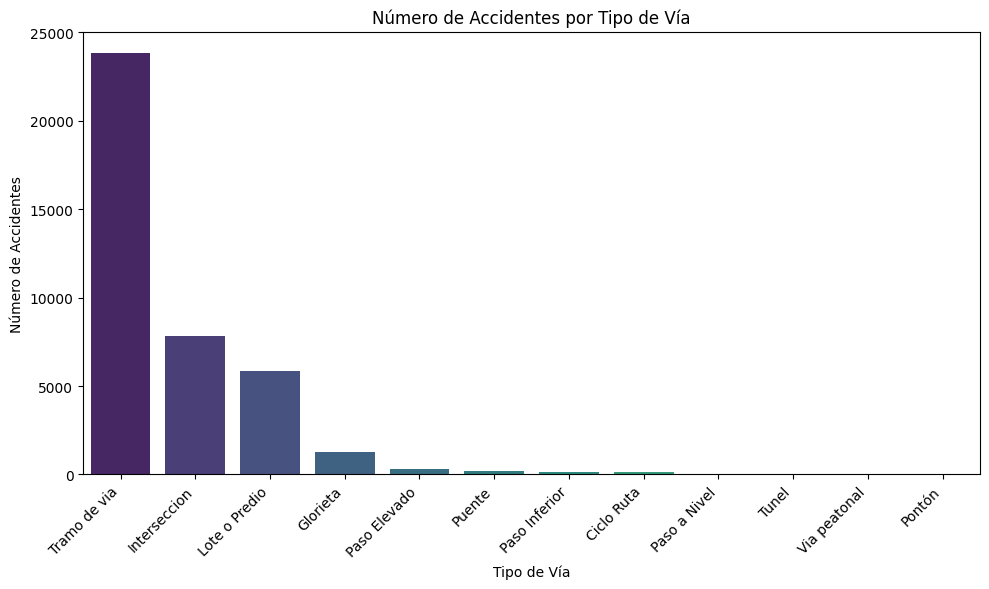

In [ ]:
accidentes_por_diseno = datos["Diseño"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=accidentes_por_diseno.index, y=accidentes_por_diseno.values, hue=accidentes_por_diseno.index, palette='viridis', legend=False)
plt.title('Número de Accidentes por Tipo de Vía')
plt.xlabel('Tipo de Vía')
plt.ylabel('Número de Accidentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
datos["HORA"].value_counts()

,count
HORA,
17,3046
16,2667
18,2517
15,2514
14,2451
13,2443
12,2359
7,2203
19,2161


In [ ]:
tabla_hora_gravedad = pd.crosstab(
    datos["RANGO_HORA"],
    datos["Gravedad Incidente"]
)

print(tabla_hora_gravedad)

Gravedad Incidente  Con heridos  Con muertos  Solo daños
RANGO_HORA                                              
0                           622           16         337
3                          1010           19         474
6                          3724           17        2349
9                          2729           24        3178
12                         3344           26        3883
15                         3767           22        4438
18                         3404           25        3084
21                         2034           23        1116


In [ ]:
tabla_diseno_gravedad = pd.crosstab(
    datos["Diseño"],
    datos["Gravedad Incidente"]
)

print(tabla_diseno_gravedad)

Gravedad Incidente  Con heridos  Con muertos  Solo daños
Diseño                                                  
Ciclo Ruta                   67            0          67
Glorieta                    328            0         965
Interseccion               3837           37        3969
Lote o Predio              4910            4         921
Paso Elevado                148            0         152
Paso Inferior                94            3          60
Paso a Nivel                 14            0          25
Pontón                        1            0           1
Puente                       98            1         113
Tramo de via              11131          126       12578
Tunel                         5            1           4
Via peatonal                  1            0           4


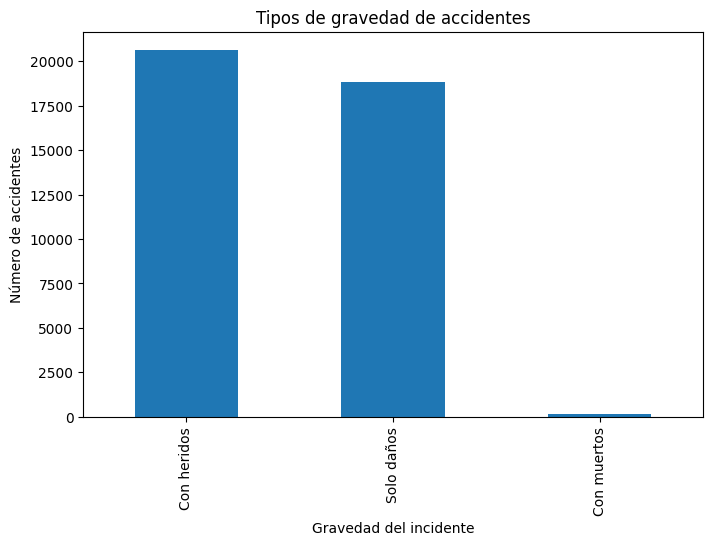

In [ ]:
datos["Gravedad Incidente"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Tipos de gravedad de accidentes")
plt.xlabel("Gravedad del incidente")
plt.ylabel("Número de accidentes")
plt.show()

In [ ]:
accidentes_comuna = datos["Comuna"].value_counts()

print(accidentes_comuna)

Comuna
10 - La Candelaria                            8251
11 - Laureles Estadio                         4390
05 - Castilla                                 4184
14 - El Poblado                               3466
15 - Guayabal                                 2958
07 - Robledo                                  2684
16 - Belén                                    2595
04 - Aranjuez                                 2295
09 - Buenos Aires                             1459
12 - La América                               1225
06 - Doce de Octubre                          1144
03 - Manrique                                 1108
08 - Villa Hermosa                            1014
80 - Corregimiento de San Antonio de Prado     622
13 - San Javier                                616
01 - Popular                                   568
02 - Santa Cruz                                557
60 - Corregimiento de San Cristóbal            392
90 - Corregimiento de Santa Elena               87
70 - Corregimiento de Al

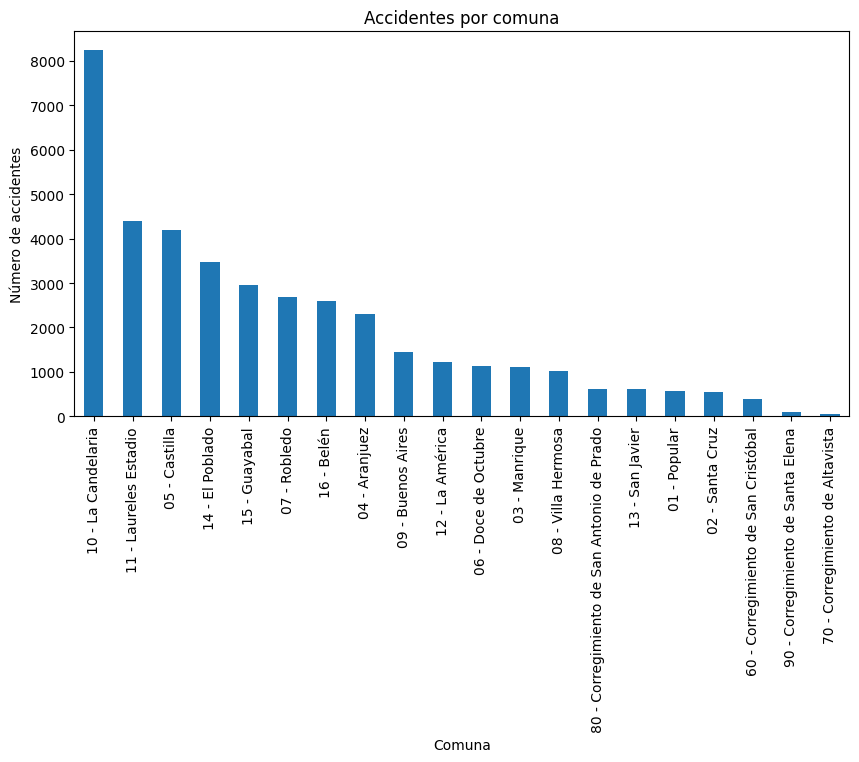

In [ ]:
accidentes_comuna.plot(kind="bar", figsize=(10,5))

plt.title("Accidentes por comuna")
plt.xlabel("Comuna")
plt.ylabel("Número de accidentes")
plt.show()

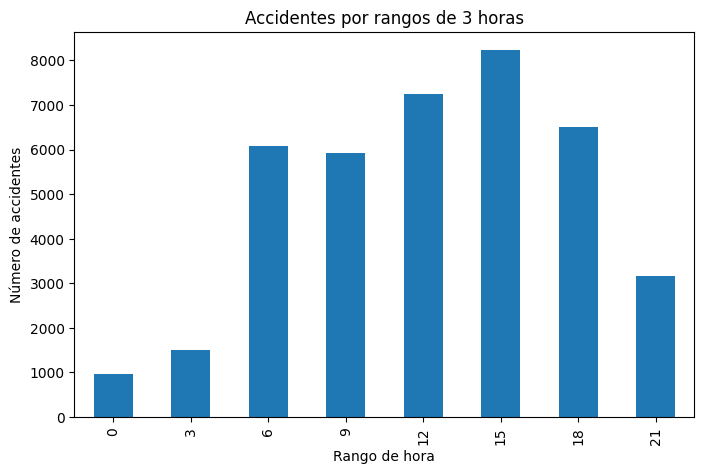

In [ ]:
accidentes_rango.plot(kind="bar", figsize=(8,5))

plt.title("Accidentes por rangos de 3 horas")
plt.xlabel("Rango de hora")
plt.ylabel("Número de accidentes")
plt.show()

Gravedad Incidente  Con heridos  Con muertos  Solo daños
RANGO_HORA                                              
0                           622           16         337
3                          1010           19         474
6                          3724           17        2349
9                          2729           24        3178
12                         3344           26        3883
15                         3767           22        4438
18                         3404           25        3084
21                         2034           23        1116


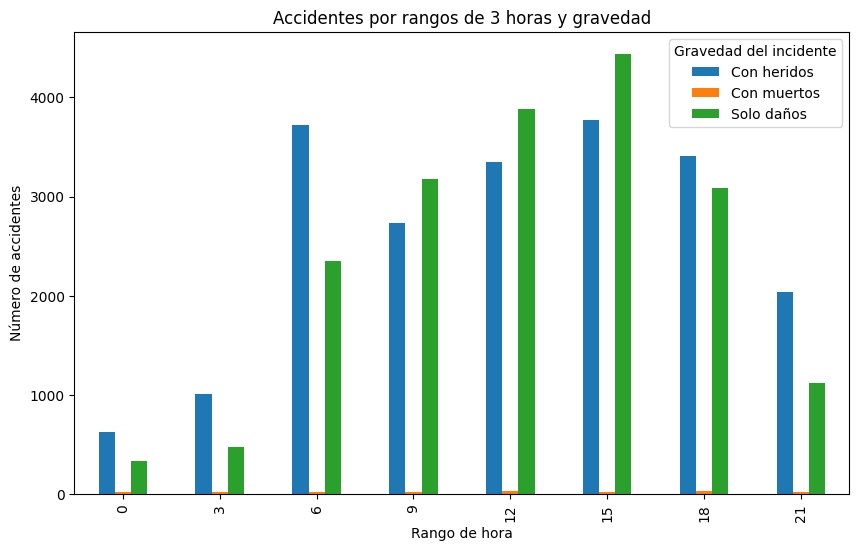

In [ ]:
tabla_rango_gravedad = pd.crosstab(
    datos["RANGO_HORA"],
    datos["Gravedad Incidente"]
)

print(tabla_rango_gravedad)
tabla_rango_gravedad.plot(kind="bar", figsize=(10,6))

plt.title("Accidentes por rangos de 3 horas y gravedad")
plt.xlabel("Rango de hora")
plt.ylabel("Número de accidentes")
plt.legend(title="Gravedad del incidente")

plt.show()

In [ ]:
top_3_clusters = accidents_per_kmeans_cluster.sort_values(ascending=False).head(3).index.tolist()

print(f"Los 3 clusters de KMeans con la mayor cantidad de accidentes son: {top_3_clusters}")

Los 3 clusters de KMeans con la mayor cantidad de accidentes son: [13, 1, 8]


In [ ]:
for cluster_id in top_3_clusters:
    print(f"\n--- Análisis del Cluster {cluster_id} ---")
    cluster_data = datos[datos['kmeans_cluster'] == cluster_id]

    # 1. Top 5 Comunas
    print(f"\nTop 5 Comunas en Cluster {cluster_id}:")
    top_communes = cluster_data['Comuna'].value_counts().head(5)
    print(top_communes)

    # 2. Top 5 Barrios
    print(f"\nTop 5 Barrios en Cluster {cluster_id}:")
    top_barrios = cluster_data['Barrio'].value_counts().head(5)
    print(top_barrios)

    # 3. Distribución de CLASE_ACCIDENTE
    print(f"\nDistribución de CLASE_ACCIDENTE en Cluster {cluster_id}:")
    accident_types_dist = cluster_data['CLASE_ACCIDENTE'].value_counts()
    print(accident_types_dist)

    # 4. Distribución de Gravedad Incidente
    print(f"\nDistribución de Gravedad Incidente en Cluster {cluster_id}:")
    severity_dist = cluster_data['Gravedad Incidente'].value_counts()
    print(severity_dist)

    # 5. Top 5 Diseños de Vía
    print(f"\nTop 5 Diseños de Vía en Cluster {cluster_id}:")
    top_designs = cluster_data['Diseño'].value_counts().head(5)
    print(top_designs)

    # 6. Distribución de accidentes por RANGO_HORA
    print(f"\nDistribución de Accidentes por RANGO_HORA en Cluster {cluster_id}:")
    hour_range_dist = cluster_data['RANGO_HORA'].value_counts().sort_index()
    print(hour_range_dist)



--- Análisis del Cluster 13 ---

Top 5 Comunas en Cluster 13:
Comuna
10 - La Candelaria    4318
09 - Buenos Aires      177
08 - Villa Hermosa      86
04 - Aranjuez           69
Name: count, dtype: int64

Top 5 Barrios en Cluster 13:
Barrio
La Candelaria     979
Barrio Colón      558
Villa Nueva       548
Boston            391
Jesús Nazareno    326
Name: count, dtype: int64

Distribución de CLASE_ACCIDENTE en Cluster 13:
CLASE_ACCIDENTE
Choque            3393
Atropello          541
Otro               324
Caida Ocupante     287
Volcamiento        104
Incendio             1
Name: count, dtype: int64

Distribución de Gravedad Incidente en Cluster 13:
Gravedad Incidente
Solo daños     2508
Con heridos    2114
Con muertos      28
Name: count, dtype: int64

Top 5 Diseños de Vía en Cluster 13:
Diseño
Tramo de via     2649
Interseccion     1360
Lote o Predio     454
Glorieta           97
Paso Inferior      47
Name: count, dtype: int64

Distribución de Accidentes por RANGO_HORA en Cluster 13:
R

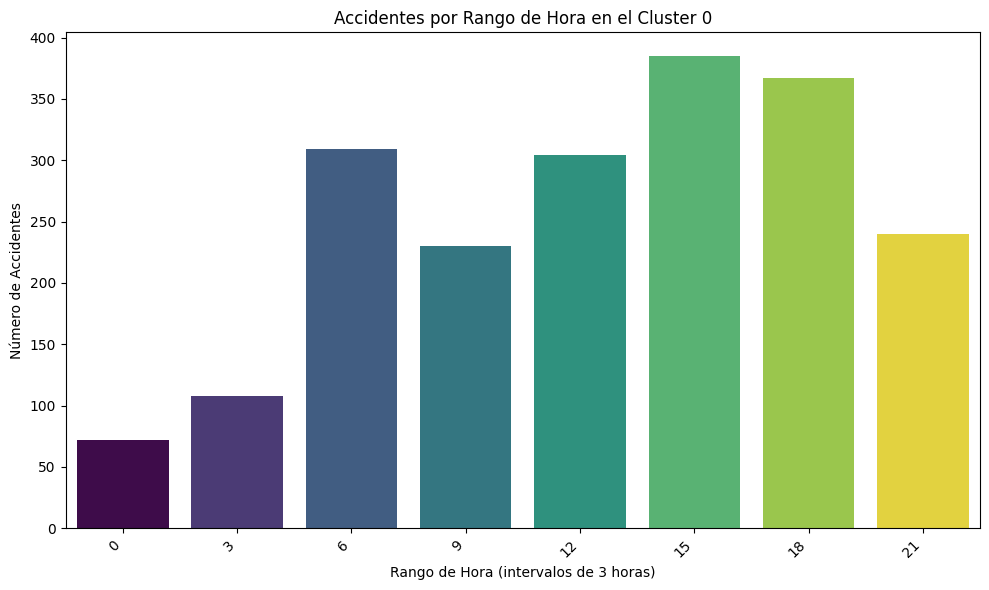

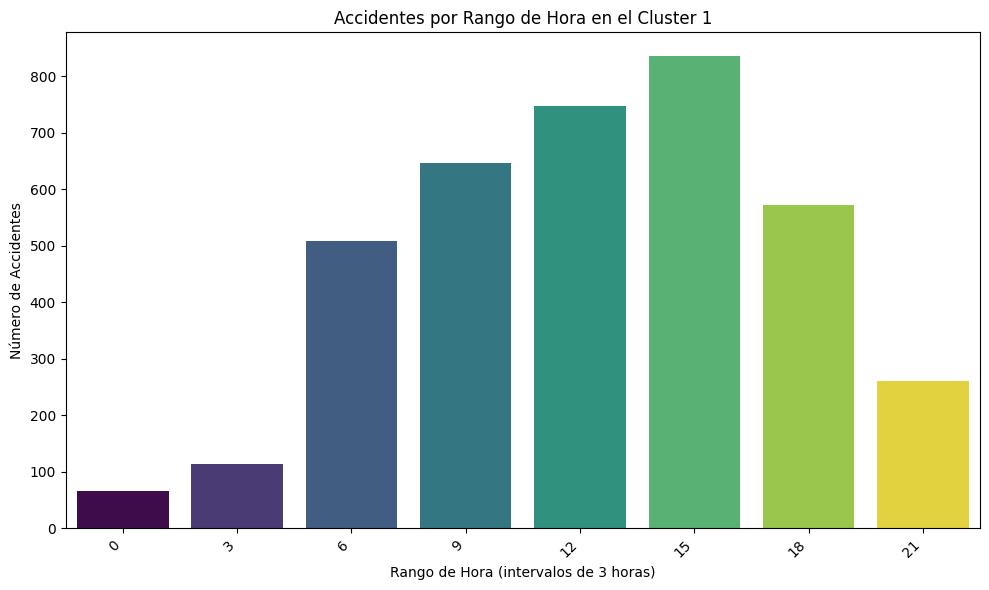

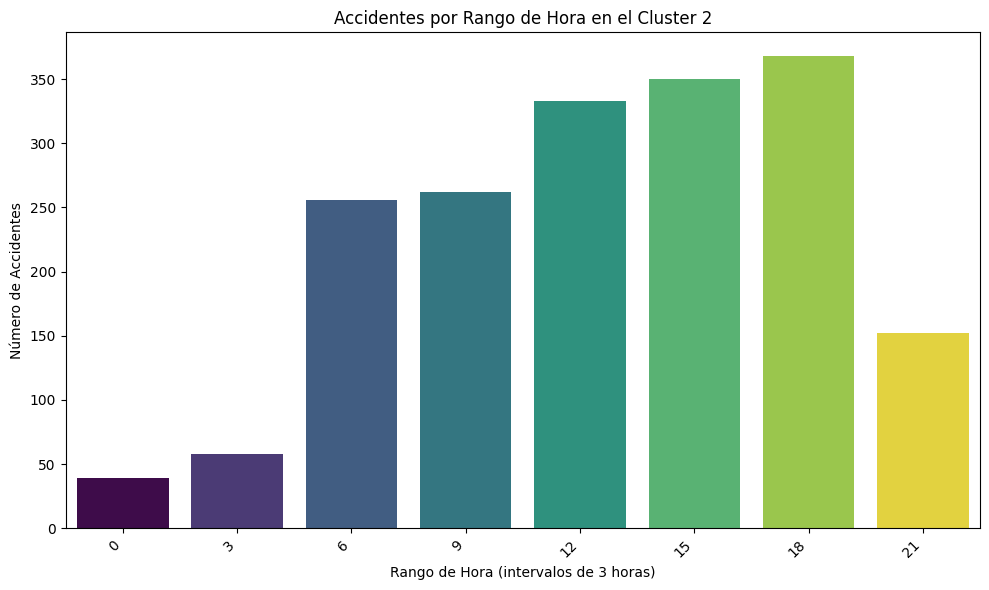

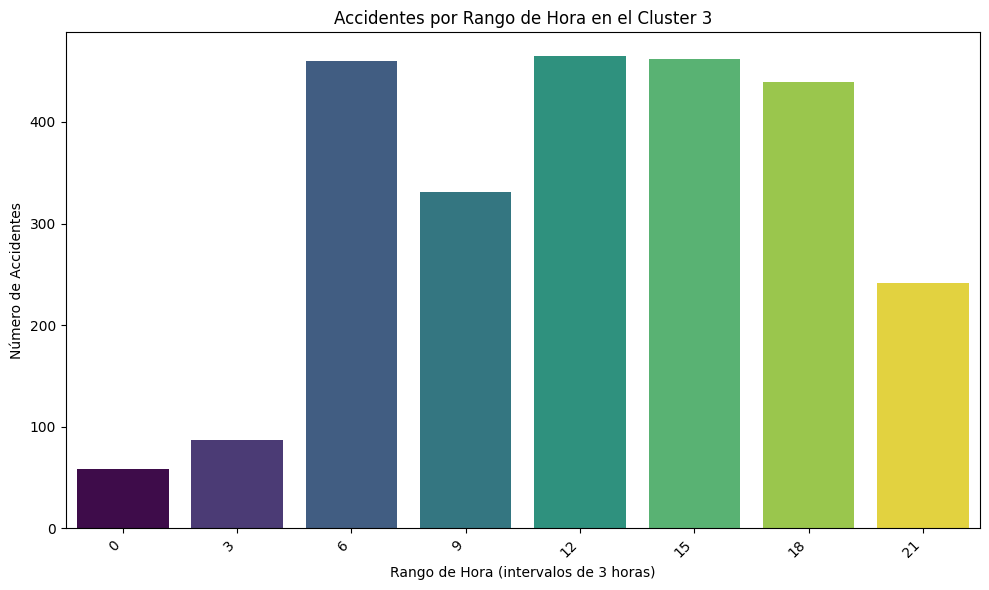

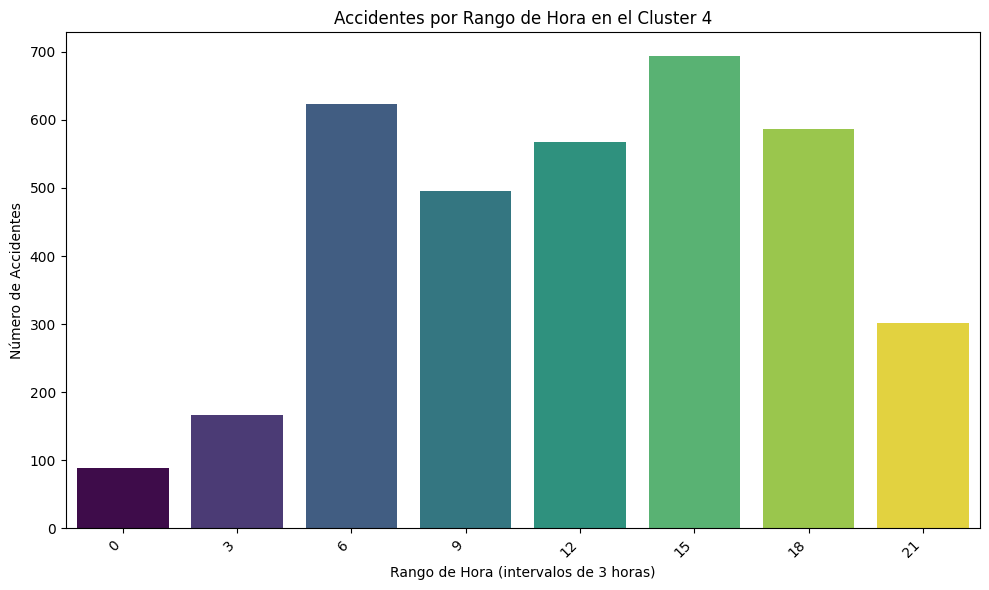

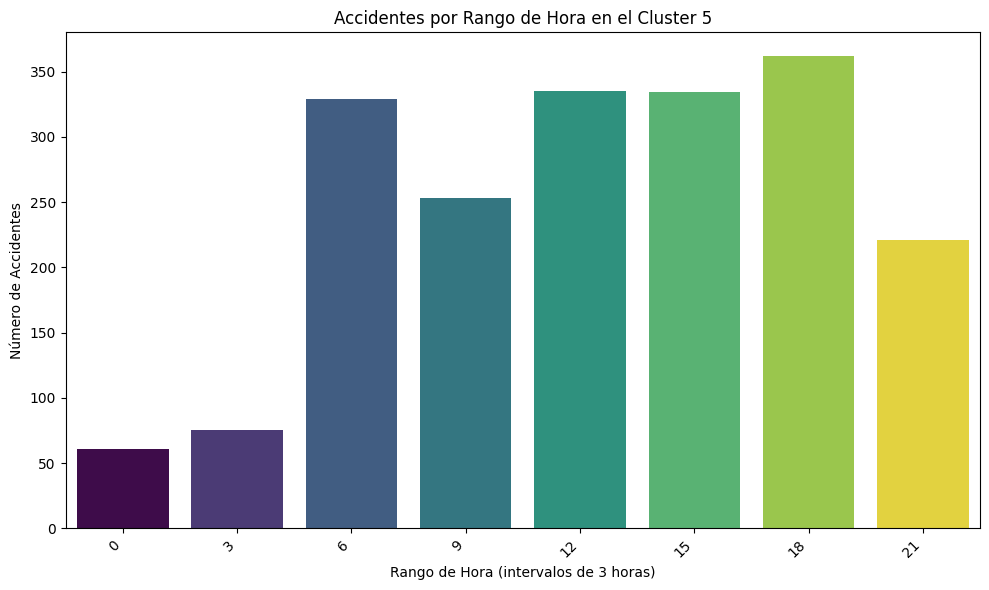

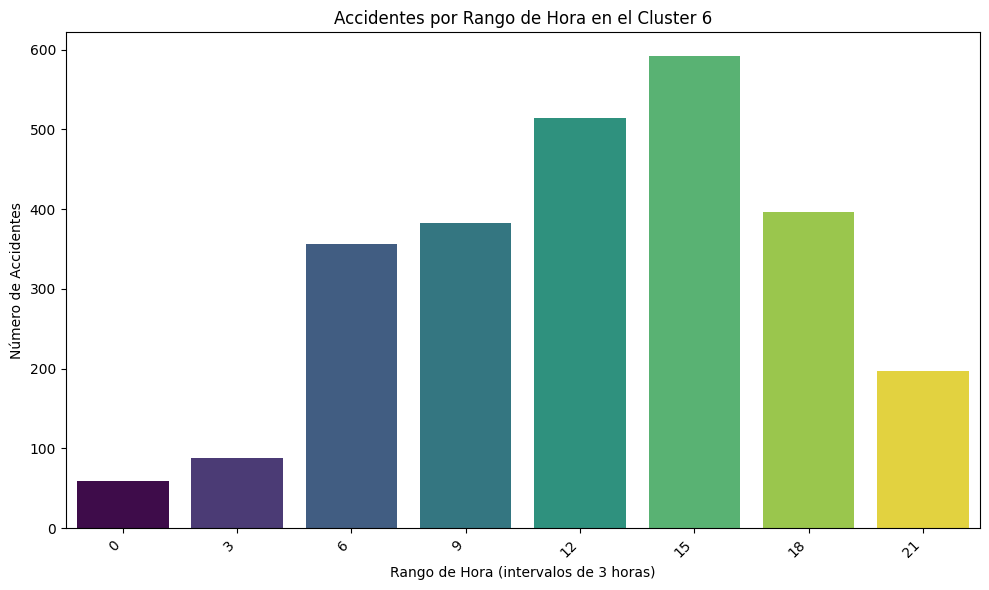

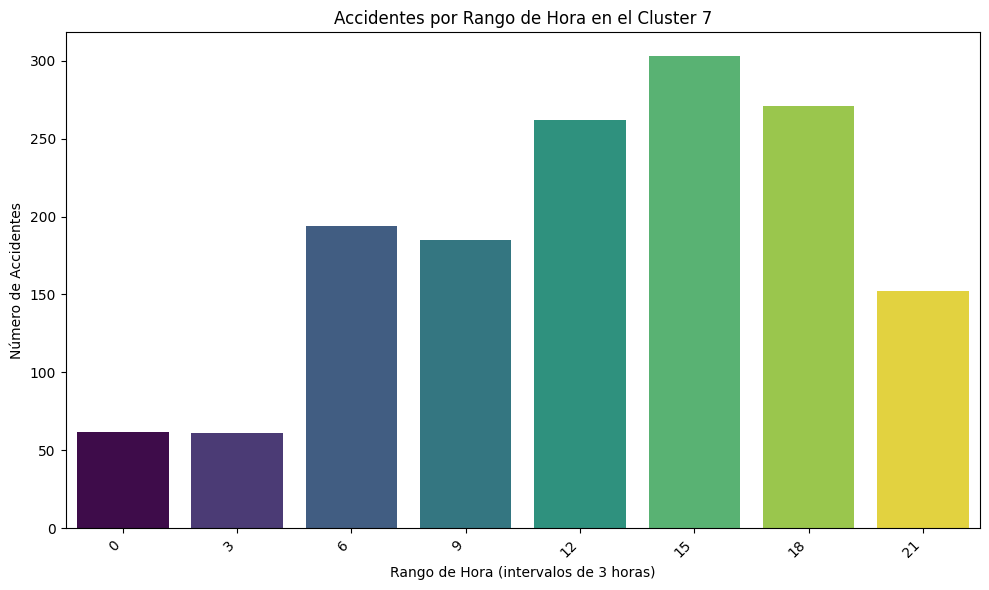

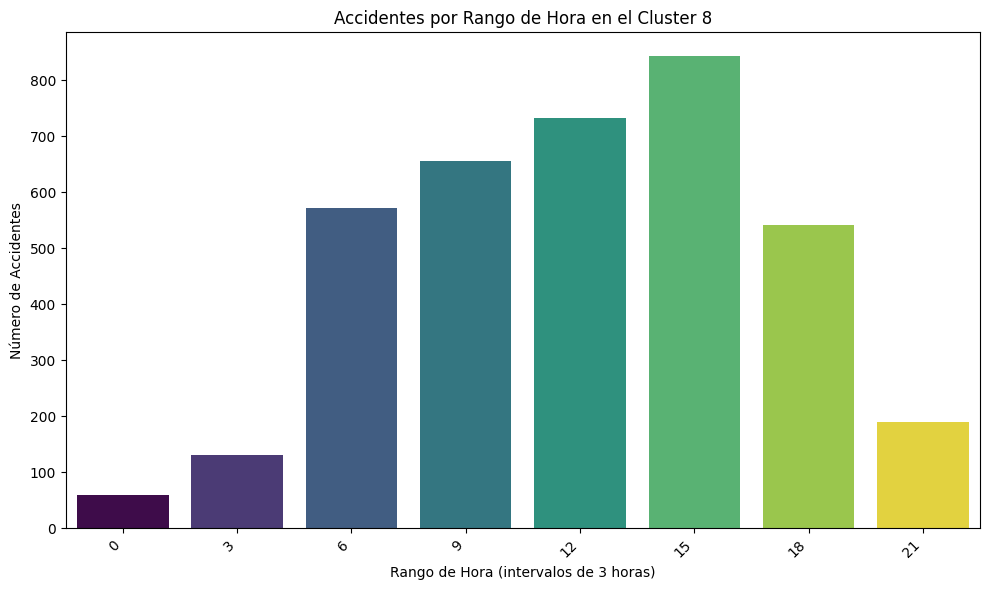

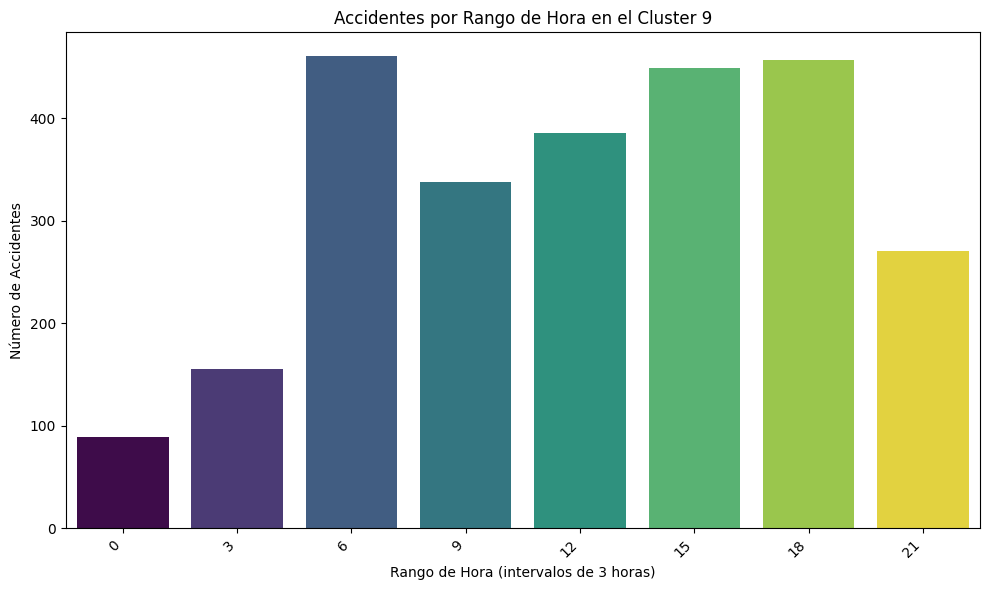

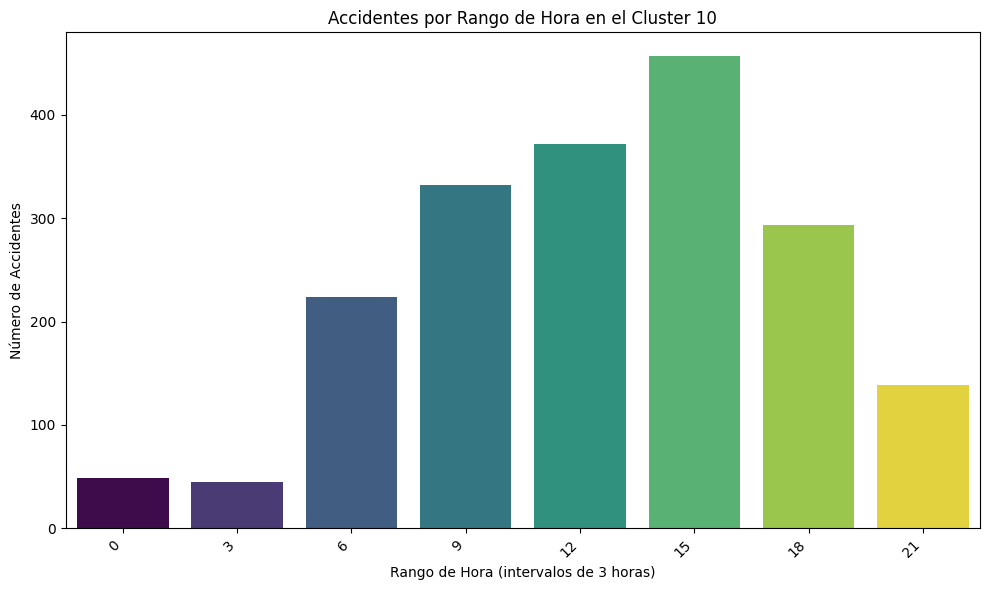

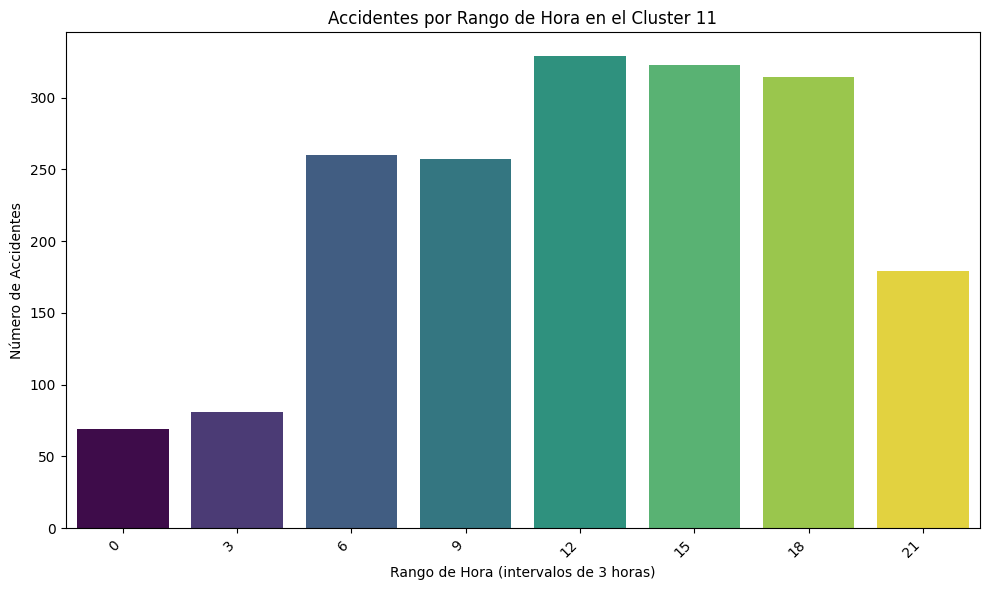

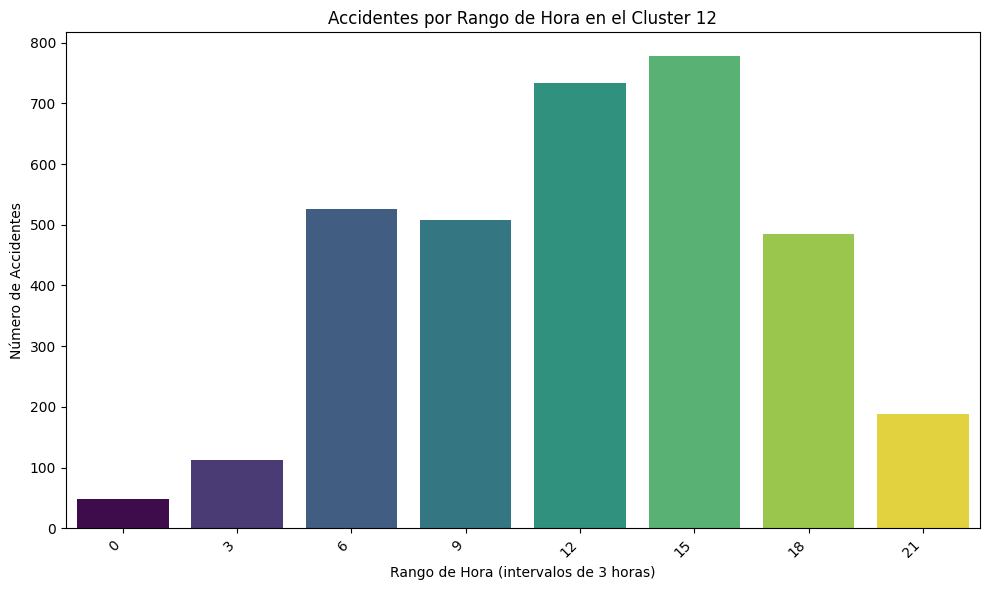

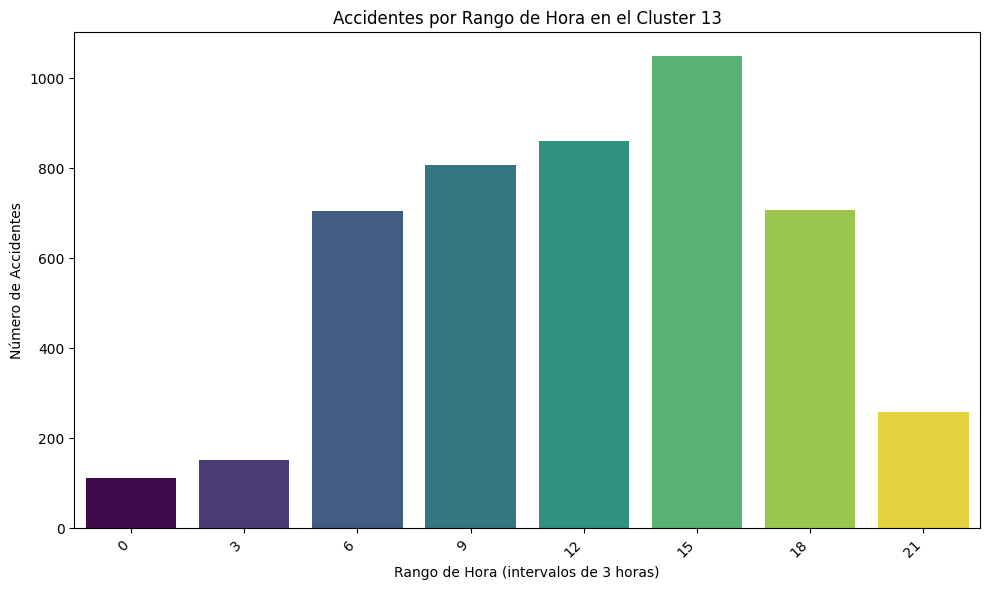

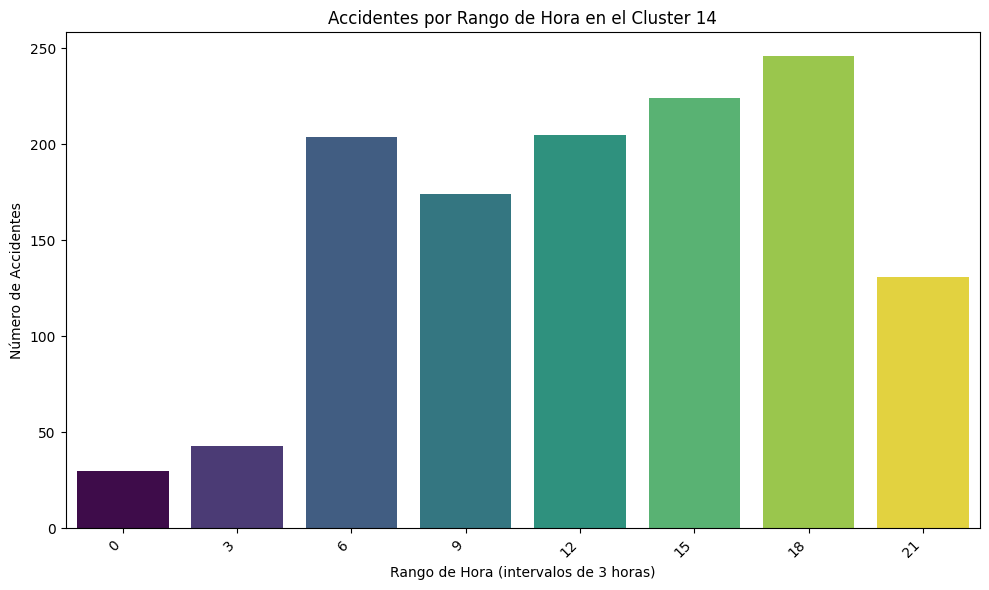

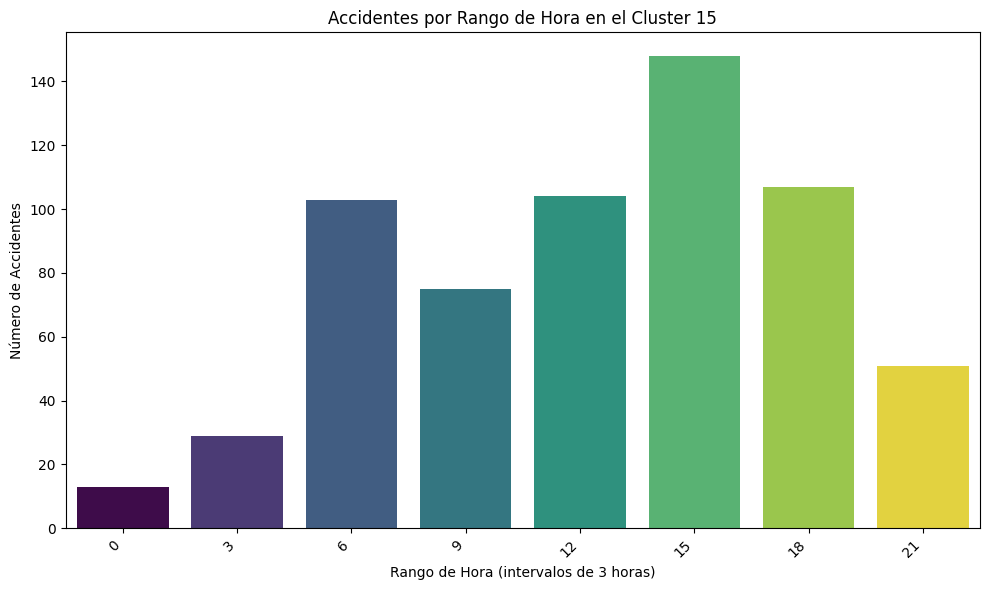

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_clusters = datos['kmeans_cluster'].unique()
unique_clusters.sort()

for cluster_id in unique_clusters:
    cluster_data = datos[datos['kmeans_cluster'] == cluster_id]

    # Distribution of accidents by RANGO_HORA for the current cluster
    accidents_by_hour_range = cluster_data['RANGO_HORA'].value_counts().sort_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(x=accidents_by_hour_range.index, y=accidents_by_hour_range.values, hue=accidents_by_hour_range.index, palette='viridis', legend=False)
    plt.title(f'Accidentes por Rango de Hora en el Cluster {cluster_id}')
    plt.xlabel('Rango de Hora (intervalos de 3 horas)')
    plt.ylabel('Número de Accidentes')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
# Filtrar accidentes con gravedad 'Con heridos' o 'Con muertos'
severe_accidents = datos[datos['Gravedad Incidente'].isin(['Con heridos', 'Con muertos'])]

# Contar accidentes severos por cluster
severe_accidents_per_cluster = severe_accidents['kmeans_cluster'].value_counts()

print("Clusters con el mayor número de accidentes severos (con heridos o muertos):")
print(severe_accidents_per_cluster.head())

# Identificar los 3 clusters principales con accidentes severos
top_severe_clusters = severe_accidents_per_cluster.head(3).index.tolist()
print(f"\nLos 3 clusters con más accidentes severos son: {top_severe_clusters}")

# Analizar los barrios dentro de estos clusters principales
print("\nAnálisis de barrios con más accidentes severos en los clusters principales:")
for cluster_id in top_severe_clusters:
    print(f"\n--- Cluster {cluster_id} ---")
    cluster_severe_data = severe_accidents[severe_accidents['kmeans_cluster'] == cluster_id]

    # Contar accidentes severos por barrio dentro del cluster
    top_barrios_severe = cluster_severe_data['Barrio'].value_counts().head(5)
    print("Top 5 Barrios con accidentes severos:")
    print(top_barrios_severe)

Clusters con el mayor número de accidentes severos (con heridos o muertos):
kmeans_cluster
13    2142
4     1912
9     1749
1     1608
8     1560
Name: count, dtype: int64

Los 3 clusters con más accidentes severos son: [13, 4, 9]

Análisis de barrios con más accidentes severos en los clusters principales:

--- Cluster 13 ---
Top 5 Barrios con accidentes severos:
Barrio
La Candelaria     354
Villa Nueva       263
Jesús Nazareno    195
Boston            194
Barrio Colón      186
Name: count, dtype: int64

--- Cluster 4 ---
Top 5 Barrios con accidentes severos:
Barrio
Caribe                    447
Terminal de Transporte    232
El Progreso               194
Moravia                   143
Universidad Nacional      135
Name: count, dtype: int64

--- Cluster 9 ---
Top 5 Barrios con accidentes severos:
Barrio
Castilla             330
Toscana              130
Tricentenario        128
Héctor Abad Gómez    128
Pedregal             119
Name: count, dtype: int64


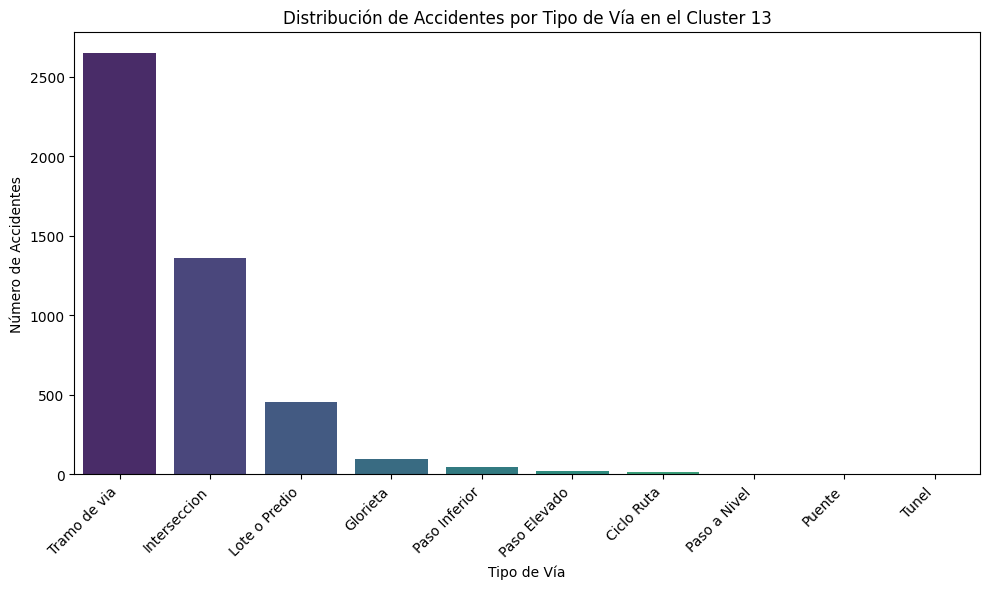

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar datos para el Cluster 13
cluster_13_data = datos[datos['kmeans_cluster'] == 13]

# Contar la distribución de accidentes por tipo de vía
design_distribution_cluster_13 = cluster_13_data['Diseño'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=design_distribution_cluster_13.index, y=design_distribution_cluster_13.values, hue=design_distribution_cluster_13.index, palette='viridis', legend=False)
plt.title('Distribución de Accidentes por Tipo de Vía en el Cluster 13')
plt.xlabel('Tipo de Vía')
plt.ylabel('Número de Accidentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
for cluster_id in [13, 1, 8]:
    cluster_data = datos[datos['kmeans_cluster'] == cluster_id]
    print(f"\n--- Top 20 direcciones Cluster {cluster_id} ---")
    print(cluster_data['DIRECCION'].value_counts().head(20))


--- Top 20 direcciones Cluster 13 ---
DIRECCION
CR 46 CL 52    82
CR 46 CL 47    72
CR 57 CL 57    63
CL 44 CR 52    63
CL 58 CR 57    56
CR 51 CL 67    52
CR 46 CL 49    50
CR 46 CL 57    50
CR 57 CL 58    48
CR 46 CL 50    46
CL 58 CR 53    44
CR 46 CL 56    42
CR 46 CL 41    42
CR 46 CL 45    41
CL 44 CR 51    39
CL 44 CR 50    39
CR 46 CL 46    36
CR 45 CL 50    36
CL 47 CR 46    35
CR 46 CL 53    34
Name: count, dtype: int64

--- Top 20 direcciones Cluster 1 ---
DIRECCION
CR 50 CL 30      96
CR 63 CL 33      68
CR 50 CL 25      64
CR 52 CL 25      59
CR 55 CL 37      55
CR 38 CL 26      51
CR 43 A CL 30    51
CR 50 CL 29      47
CR 48 CL 20      42
CR 55 CL 41      40
CL 37 CR 55      35
CR 43 A CL 34    34
CL 33 CR 63      34
CL 37 CR 52      33
CL 30 CR 55      31
CL 30 CR 65      29
CL 37 CR 43 A    29
CR 50 CL 32      28
CL 37 CR 43      27
CR 49 CL 30      27
Name: count, dtype: int64

--- Top 20 direcciones Cluster 8 ---
DIRECCION
CR 57 CL 44    152
CL 44 CR 57    108
CR 63

##1. Resumen Ejecutivo

Este informe documenta el proceso de análisis de clustering aplicado a la accidentalidad georreferenciada de Medellín en 2018. El objetivo es identificar zonas de alta concentración de accidentes para orientar la asignación de guardias de tránsito, ambulancias y demás servicios de emergencia de forma basada en datos.
De los 43.306 registros originales se retuvieron 39.665 tras el proceso de limpieza geoespacial (91,6 %). Se evaluaron tres modelos de clustering — KMeans, DBSCAN y Clustering Jerárquico Aglomerativo — seleccionándose KMeans con k=16 como solución final por ofrecer la mejor combinación entre calidad estadística y granularidad operativa.
Los tres clusters de mayor accidentalidad (C13 Centro, C1 Sur-Centro y C8 Laureles) concentran el 30,6 % de todos los accidentes y el 35,5 % de las muertes registradas en el año. La intersección CR 57 × CL 44 resultó el punto individual más peligroso de toda la ciudad, con 260 registros acumulados en ambos sentidos.

##2. Descripción del Dataset

El dataset utilizado es la Accidentalidad Georreferenciada 2018 de la Secretaría de Movilidad de Medellín, disponible en el portal de datos abiertos del municipio. Contiene el registro de todos los incidentes viales reportados durante 2018 con sus coordenadas geográficas y atributos del incidente.
El archivo original cuenta con 43.306 registros y 17 variables que incluyen coordenadas (Latitud y Longitud), tipo de accidente (CLASE_ACCIDENTE), nivel de gravedad (Solo daños / Con heridos / Con muertos), dirección en notación local, barrio, comuna, diseño de la vía, fecha y hora del incidente. Variables auxiliares como CBML (4.328 nulos), _metodo_lat y _metodo_barrio registraban el método de geocodificación y fueron descartadas al no aportar valor analítico.

##3. Limpieza y Transformación de Datos
Criterios de depuración
El proceso de limpieza estuvo enfocado exclusivamente en garantizar la integridad geoespacial de los datos. Dado que el análisis es espacial, cualquier coordenada errónea o inventada habría generado clusters artificiales sin correspondencia con la realidad vial de la ciudad. Se aplicaron cuatro filtros secuenciales:
•	Direcciones fantãsma: 755 registros con el patrón «999» en el campo de dirección, indicativo de registros de prueba o ingresos sin dirección real en el sistema.
•	Coordenadas por centroide de comuna: 495 registros cuya ubicación había sido asignada automáticamente al punto central de la comuna (campo _metodo_lat = ‘centroide_comuna’). Al no representar el sitio real del accidente, su inclusión habría creado agrupaciones artificiales en los centros geométricos de cada comuna.
•	Coordenada fantãsma compartida: 1.683 registros —el 3,9 % del dataset original— compartían exactamente la misma coordenada (6.221806, −75.703816), ubicada fuera del perímetro municipal. Esta concentración masiva en un único punto habría generado un cluster falso de gran peso, distorsionando por completo el modelo.
•	Bounding box del municipio: 630 registros adicionales fuera del rectángulo geográfico de Medellín (lat 6,17°–6,32° / lon −75,68°–−75,51°). Su eliminación garantiza que el 100 % de los datos corresponda al territorio municipal.

El hallazgo más importante de esta fase fue la detección de que el 3,9 % del dataset apuntaba a una única coordenada inexistente fuera del municipio. De no haberse identificado, el modelo habría producido un cluster principal completamente ficticio, invalidando cualquier conclusión operativa. Tras los cuatro filtros y la eliminación de 78 registros nulos adicionales, el dataset final quedó en 39.665 registros (91,6 % del total original).
Transformaciones aplicadas
Para el análisis temporal se derivaron dos variables a partir de HORA_ACCIDENTE: la hora numérica (0–23) y el rango horario en franjas de 3 horas. Para el modelado se utilizaron únicamente Latitud y Longitud, estandarizadas con StandardScaler, ya que el objetivo es la segmentación espacial y el escalado evita que diferencias de magnitud distorsionen el cálculo de distancias.

##4. Análisis Exploratorio de Datos
Gravedad de los incidentes
El 52,0 % de los accidentes generaron heridos y el 47,6 % solo daños materiales. Aunque los accidentes fatales representan apenas el 0,4 %, en términos absolutos suman 172 muertes en un año, equivalente a casi una muerte cada dos días.
Clases de accidente
El choque domina con el 70,1 % de los casos (27.815), convirtiendo la gestión del tráfico vehicular en la intervención de mayor impacto potencial. Los atropellos representan el 8,8 % (3.474) y tienen relevancia especial por su mayor letalidad. Los volcamientos (2,9 %, 1.152 casos), aunque menos frecuentes, requieren equipos especializados de extricación y concentrarse principalmente en corredores de alta velocidad.
Diseño vial y gravedad
El hallazgo más relevante de esta dimensión es el tipo «Lote o Predio»: con 5.835 accidentes registrados, el 84,2 % resultaron con heridos, la proporción más alta de todo el dataset. Las entradas a estacionamientos y predios privados son un punto ciego sistemático que no suele aparecer en los mapas de calor tradicionales pero que genera una accidentalidad con heridos desproporcionada. Las intersecciones concentran 37 de los 172 muertos (21,5 %), siendo el segundo diseño más letal después de los tramos de vía.
Distribución temporal
La franja 15h–18h es la más peligrosa con 8.227 accidentes (20,7 % del total anual). Existe un patrón bimodal claro: un pico matutino en la entrada laboral (6h–9h, 6.090 acc.) y un pico vespertino más pronunciado en la salida (15h–18h). Los accidentes entre medianoche y las 6h representan solo el 6,3 % del total, lo que justifica reducir los turnos nocturnos de vigilancia en la mayoría de sectores.
Distribución por comunas
La Candelaria concentra 1 de cada 5 accidentes de toda la ciudad (8.251, el 20,8 %). Las cinco comunas de mayor siniestralidad — La Candelaria, Laureles-Estadio, Castilla, El Poblado y Guayabal — agrupan el 58,7 % del total. Esta elevada concentración anticipa el resultado del modelo de clustering y valida que una estrategia de despliegue uniforme para toda la ciudad sería ineficiente.

##5. Modelos de Clustering
Enfoque y métrica de evaluación
Se evaluaron tres algoritmos con distintos paradigmas de agrupamiento, utilizando Latitud y Longitud estandarizadas como únicas variables de entrada. La calidad de cada modelo se midió con el Índice de Silhouette, que evalúa qué tan bien definidos y separados están los clusters en un rango de −1 a +1, donde valores más altos indican mejor separación.
KMeans
Se probó con valores de k entre 2 y 24. El mejor silhouette para el k óptimo fue 0,3854 con k=5, pero se adoptó k=16 para lograr granularidad operativa suficiente por zona de la ciudad. Con k=16 el score fue de 0,3838, considerado aceptable para datos geoespaciales urbanos de alta densidad. Su principal ventaja es que opera sobre el dataset completo, produce centroides directamente interpretables como coordenadas de posicionamiento y permite clusters de tamaño variable según la densidad real de cada zona.
DBSCAN
Obtuvo el mejor silhouette score del estudio (0,5195), lo que lo convierte en el mejor modelo estadísticamente. Sin embargo, solo identificó 2 clusters: el núcleo urbano central y el corregimiento de Altavista. Esta separación bipartita, aunque válida matemáticamente, es insuficiente para una asignación operativa diferenciada por sectores de la ciudad.
Clustering Jerárquico Aglomerativo
Debido a su complejidad computacional, se trabajó sobre una muestra de 3.000 puntos, lo que limita su representatividad. Obtuvo el score más bajo del estudio (0,3402) y requirió el mayor número de clusters (k=22) para resultados comparables. No fue seleccionado como modelo final.
Selección del modelo final: KMeans k=16
KMeans con k=16 fue seleccionado por ofrecer la mejor combinación entre calidad estadística aceptable (Silhouette 0,3838), cobertura del dataset completo y granularidad suficiente para diferenciar zonas operativas dentro de la ciudad. DBSCAN, aunque estadísticamente superior, genera solo 2 grupos, lo que hace inviable la asignación diferenciada de recursos. El clustering jerárquico, por su parte, sacrifica representatividad al requerir submuestreo y obtiene el peor score.

##6. Caracterización de los Clusters
Distribución general
Los 16 clusters presentan tamaños muy heterogéneos, desde 630 accidentes (C15, corregimientos) hasta 4.650 (C13, Centro). Esta variabilidad refleja la distribución espacial real de la siniestralidad urbana: muy concentrada en el centro histórico y sus comunas adyacentes, y progresivamente más dispersa hacia la periferia y los corregimientos. El 87,5 % de los clusters tiene su hora pico en la franja 15h–18h, confirmando el patrón vespertino como fenómeno transversal a toda la ciudad.
Cluster 13 — Centro de Medellín
Con 4.650 accidentes y 28 muertos, es el cluster de mayor accidentalidad y mortalidad absoluta. La Candelaria concentra el 92,9 % de sus accidentes. La Avenida Oriental (CR 46) es el eje crítico del cluster: aparece en 7 de los 15 puntos de mayor accidentalidad, liderados por CR 46 × CL 52 (82 accidentes), CR 46 × CL 47 (72) y CL 44 × CR 52 (63). El 73 % son choques y el 11,6 % atropellos, patrón que señala alta fricción entre flujos vehiculares rápidos y cruces peatonales en el centro histórico. El centroide se ubica en las coordenadas 6,25007 N / 75,56542 W, con un radio medio de 0,73 km y el 78,9 % de los accidentes dentro de 1 km.
Cluster 1 — Sur-Centro
Con 3.750 accidentes y 17 muertos, su punto más accidentado es CR 50 × CL 30 con 96 incidentes. Destaca por tener el mayor número de volcamientos de todos los clusters (107 casos), asociados a la Autopista Sur y el Paso Elevado de Guayabal. Presenta la mejor ventaja de cobertura hospitalaria: su centroide (6,23234 N / 75,57476 W) se ubica a apenas 550 m del Hospital General de Medellín, el recurso hospitalario más cercano de todos los clusters prioritarios.
Cluster 8 — Laureles-Estadio
Contiene el punto geográfico más peligroso de toda la ciudad: la intersección CR 57 × CL 44, que acumula 260 registros sumando ambos sentidos de notación (152 + 108). La CL 44 completa entre CR 57 y CR 65 es el tramo continuo de mayor siniestralidad del dataset. Con un radio medio de 0,68 km y el 84,5 % de sus accidentes dentro de 1 km del centroide (6,25054 N / 75,57945 W), es el cluster más compacto del análisis y por tanto el candidato óptimo para posicionamiento fijo de ambulancia.
Hallazgo singular — Cluster 9
El Cluster 9 (Castilla – Doce de Octubre) es el único con hora pico a las 6h de la mañana, en contraste con el patrón de 15h–18h compartido por el 87,5 % de los clusters. Con 15 muertos, es el tercer cluster más letal del dataset. Este patrón señala accidentalidad estructurada por la entrada laboral y escolar temprana en una zona de carácter industrial-residencial del noroccidente, y actualmente no existe ningún turno diferenciado de vigilancia para ese horario en el sector.
Cluster 14 — San Cristóbal
Es el cluster más disperso del análisis con un radio medio de 1,63 km. Solo el 1,0 % de sus accidentes ocurre a 500 m del centroide y el 20,5 % dentro de 1 km, lo que significa que el centroide calculado no es representativo como punto de posicionamiento. Este cluster requiere ser subdivididido en al menos tres sub-zonas a lo largo del corredor San Cristóbal – San Javier para una cobertura efectiva.
Cluster 15 — Corregimientos
Con solo 630 accidentes es el cluster de menor volumen, pero presenta el mayor riesgo por tiempo de respuesta de todo el análisis. No cuenta con ninguna estación de bomberos propia, el hospital local es de baja complejidad y el acceso a urgencias de alta complejidad demora entre 15 y 25 minutos por vías sinuosas. Los accidentes en esta zona tienden a ser de mayor gravedad por velocidad elevada en curvas.

##7. Análisis de Centroides
Utilidad operativa
El centroide de cada cluster KMeans es la coordenada geográfica que minimiza la distancia promedio a todos los accidentes del grupo. Esto lo convierte directamente en el punto de posicionamiento óptimo de un recurso de emergencia: si una ambulancia o patrulla se estaciona allí, minimiza su tiempo promedio de respuesta a todos los incidentes del cluster.
Hallazgos por compacidad
El análisis del radio medio y el porcentaje de accidentes dentro de 1 km revela diferencias críticas entre clusters. El Cluster 8 (Laureles) es el más compacto: el 84,5 % de sus accidentes ocurre dentro de 1 km del centroide, lo que significa que una única unidad estacionada en ese punto cubre prácticamente toda la zona. Los clusters C1 (81,7 %) y C13 (78,9 %) tienen compacidad similar. En el extremo opuesto, el Cluster 14 (San Cristóbal) con solo el 1,0 % a 500 m es un caso donde el centroide no debe usarse como punto de posicionamiento: el territorio del cluster tiene forma alargada y el centroide queda en una zona sin accidentes representativos.
Brechas centroide–servicios de emergencia
Cruzando las coordenadas de cada centroide con la ubicación de los servicios de emergencia existentes se identifican las brechas de cobertura más críticas. El centroide del Cluster 8 está a 2,5 km de la estación de bomberos más cercana, a pesar de contener el punto más accidentado de la ciudad. El Cluster 1 tiene la mejor situación hospitalaria con su centroide a solo 550 m del Hospital General. El Cluster 15 no tiene ninguna estación de bomberos a menos de 12 km. El Cluster 9, con 15 muertos, tampoco cuenta con bomberos a menos de 2,5 km de su centroide.
Uso dinámico para seguimiento anual
Una aplicación adicional de los centroides es el seguimiento temporal: si el mismo modelo se aplica a datos de años posteriores y los centroides se desplazan, significa que las zonas de mayor riesgo están migrando dentro de la ciudad. Esto permitiría ajustar el posicionamiento de servicios año a año con una metodología reproducible y basada en datos.

##8. Servicios de Emergencia por Cluster
Cobertura en los clusters prioritarios
El Cluster 13 (Centro) es el mejor cubierto de la ciudad con seis centros hospitalarios, dos estaciones de bomberos y estación de policía dentro de su área. La Clínica Soma está a 720 m del centroide y la Estación de Policía Centro a apenas 300 m. La única brecha relevante es la cobertura nocturna (0h–3h) en los barrios Villa Hermosa y Buenos Aires, que quedan a más de 15 minutos de la estación más cercana.
El Cluster 1 (Sur-Centro) tiene buena cobertura hospitalaria gracias a su proximidad al Hospital General (550 m) y la Clínica del Sur (1.590 m). La brecha más crítica es bomberil: la Estación Guayabal está a 4 km del punto de mayor accidentalidad del cluster (CR 50 × CL 30), lo que implica tiempos de respuesta de 8 a 12 minutos en hora pico. No existe una subestación intermedia.
El Cluster 8 (Laureles) presenta la brecha crítica más seria del análisis: no tiene ninguna estación de bomberos propia dentro de su área. La más cercana (Estación Libertadores) está a 820 m del centroide en condiciones normales, pero en días de evento deportivo en el Estadio Atanasio la congestón puede duplicar ese tiempo de acceso. Tiene buena cobertura hospitalaria con la Clínica Las Américas (920 m) y cobertura policial con la Estación Laureles dentro del cluster.
Clusters con mayor vulnerabilidad de respuesta
El Cluster 15 (San Antonio de Prado y Altavista) no cuenta con ninguna estación de bomberos. La más cercana (Estación Guayabal) demora entre 12 y 20 minutos en llegar por vías sinuosas. El hospital local es de baja complejidad y el traslado a urgencias de alta complejidad tarda entre 15 y 25 minutos. Es el cluster con mayor riesgo de mortalidad evitable por tiempo de respuesta, aunque sea el de menor volumen absoluto de accidentes.
El Cluster 9 (Castilla – Doce de Octubre) combina 15 muertes registradas, hora pico a las 6h de la mañana y ausencia de cobertura bomberil a menos de 2,5 km del centroide. Es el caso de mayor desproporción entre riesgo real y capacidad de respuesta instalada.

##9. Hallazgos Principales
Geoespaciales
•	El punto CR 57 × CL 44 acumula 260 accidentes (ambos sentidos), siendo el más peligroso de toda la ciudad, y no cuenta con estación de bomberos a menos de 2,5 km.
•	La CR 46 (Av. Oriental) concentra 7 de los 15 puntos críticos del Cluster 13, constituyéndose como el corredor de mayor prioridad de intervención en el centro.
•	Los tres clusters prioritarios (C13, C1 y C8) suman 12.123 accidentes y 61 muertos, el 30,6 % y 35,5 % del total respectivamente.
•	El Cluster 14 (San Cristóbal) tiene un centroide no representativo: solo el 1,0 % de sus accidentes ocurre a 500 m de él. Requiere subdivisión en sub-zonas.
Temporales
•	La franja 15h–18h es la de mayor accidentalidad en 14 de los 16 clusters. Una política de refuerzo en ese período impactaría en el 87,5 % del territorio.
•	El Cluster 9 es el único con hora pico a las 6h. No existe turno diferenciado actual para ese horario en el sector noroccidental.
•	Los accidentes entre 0h y 6h representan el 6,3 % del total, lo que justifica una reducción significativa de los turnos nocturnos en la mayoría de clusters.
Por diseño vial
•	Los accidentes en Lote o Predio (5.835 casos) tienen la mayor razón heridos/total (84,2 %). Son un punto ciego sistemático que no suele contemplarse en los planes de fiscalización vial.
•	Las intersecciones concentran el 21,5 % de los muertos. Las fases semafóricas exclusivas para peatónes y las auditorías de visibilidad son la intervención más directa.
De cobertura de servicios
•	El Cluster 8 no tiene estación de bomberos propia, pese a contener el punto más accidentado de la ciudad.
•	El Cluster 15 tiene el mayor riesgo de mortalidad evitable por tiempo de respuesta: sin bomberos, con hospital de baja complejidad y 15–25 minutos de traslado a urgencias.
•	El Cluster 9 combina alta mortalidad (15 muertos), hora pico atípica (6h) y ausencia de cobertura bomberil adecuada.

##11. Conclusiones
El análisis de clustering de la accidentalidad georreferenciada de Medellín 2018 demuestra que la siniestralidad vial en la ciudad tiene una distribución espacial profundamente heterogénea que no puede gestionarse con una estrategia uniforme. Los 16 clusters identificados presentan patrones diferenciados de volumen, gravedad, tipo de accidente y horario, lo que hace necesaria una asignación de recursos específica por zona.
KMeans con k=16 ofrece la mejor solución para propósitos operativos: sus centroides son directamente utilizables como coordenadas de posicionamiento, su Silhouette score de 0,3838 es aceptable para datos geoespaciales urbanos densos, y su granularidad de 16 zonas es suficiente para la toma de decisiones diferenciada.
Los hallazgos más accionables son tres: primero, la intersección CR 57 × CL 44 en Laureles es el punto crítico más urgente y el que presenta la mayor brecha entre riesgo y cobertura bomberil. Segundo, el Cluster 9 requiere un turno diferenciado de madrugada que hoy no existe. Tercero, los accidentes en Lotes y Predios representan un punto ciego sistemático que afecta a todos los clusters con una razón de heridos del 84,2 %.
Como líneas de trabajo futuro, se recomienda actualizar el análisis con datos más recientes para detectar migraciones de los clusters, enriquecer el modelo con variables como tipo de vía, velocidad máxima y condiciones climáticas, y subdividir el Cluster 14 (San Cristóbal) cuyo centroide no es representativo de la distribución real de sus accidentes.
